# Evaluación 1 – Calidad y Preparación de Datos

**Integrantes:**
- Amaro Erices – amaro.erices2201@alumnos.ubiobio.cl
- Felipe Faundez – felipe.faundez2301@alumnos.ubiobio.cl
- Massimiliano Caffarena – massimiliano.caffarena2301@alumnos.ubiobio.cl
- Matias Arrepol – matias.arrepol2301@alumnos.ubiobio.cl

## 0. Carga de datos

In [5]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy import stats as scipy_stats
import unicodedata
import pandas as pd
from google.colab import data_table
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from google.colab import files

pd.set_option("display.max_columns", None)

# URL del dataset
url = "https://raw.githubusercontent.com/chupetesuazo1/IA/main/E1%20-%20EDA/rendimiento_academico_evaluacion.csv"
output_filename = "rendimiento_academico_evaluacion.csv"

# Descargar el dataset
!wget -O {output_filename} {url}

# Verificar que se haya descargado correctamente
if os.path.exists(output_filename):
    print(f"'{output_filename}' descargado exitosamente.")
else:
    print(f"Error al descargar '{output_filename}'.")

# Cargar el dataset
df = pd.read_csv(output_filename)

# Guardar una copia del dataset original
df_original = df.copy()

# Mostrar las primeras filas
df.head()

--2026-09-04 13:27:10--  https://raw.githubusercontent.com/chupetesuazo1/IA/main/E1%20-%20EDA/rendimiento_academico_evaluacion.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 382638 (374K) [text/plain]
Saving to: ‘rendimiento_academico_evaluacion.csv’

rendimiento_academi 100%[===================>] 373.67K  --.-KB/s    in 0.08s   

2026-09-04 13:27:11 (4.54 MB/s) - ‘rendimiento_academico_evaluacion.csv’ saved [382638/382638]

'rendimiento_academico_evaluacion.csv' descargado exitosamente.


,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
0,STU-10522,22.0,10.70,83.73,6.09,69.15,6.27,4.39,Sí,Ingeniería Industrial,3.96
1,STU-10947,65.0,9.86,99.60,6.76,76.95,6.52,8.03,No,Ingeniería Informática,5.09
2,STU-11352,26.0,13.43,92.65,6.07,95.99,6.70,6.37,No,Contador Auditor,4.37
3,STU-12298,27.0,20.77,81.73,5.09,90.96,6.16,5.81,No,Contador Auditor,4.02
4,STU-13527,20.0,6.27,70.17,4.84,64.20,6.30,4.10,No,Ingeniería Civil,3.24


## 1. Diagnóstico de calidad de datos

### 1.1 Caracterización del dataset (4 pts)

In [6]:
print("Registros:", df.shape[0])
print("Variables:", df.shape[1])
print()
print(df.dtypes)
print()

# TODO: separar según lo que observen en dtypes / nombres de columna
variables_numericas = df.select_dtypes(include=np.number).columns.tolist()
variables_categoricas = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numéricas:", variables_numericas)
print("Categóricas:", variables_categoricas)

Registros: 5100
Variables: 11

StudentID                object
Age                     float64
StudyHours              float64
Attendance              float64
PreviousGPA             float64
AssignmentsCompleted    float64
SleepHours              float64
InternetHours           float64
Scholarship              object
Program                  object
FinalGrade              float64
dtype: object

Numéricas: ['Age', 'StudyHours', 'Attendance', 'PreviousGPA', 'AssignmentsCompleted', 'SleepHours', 'InternetHours', 'FinalGrade']
Categóricas: ['StudentID', 'Scholarship', 'Program']


### Identificador y variable de resultado académico

Guiándonos por los nombres, la variable que corresponde al identificador y la variable que corresponde al resultado académico son StudentID y FinalGrade, pero para estar seguros, las estudiaremos a continuación:


In [7]:
# Evidencia para identificar cada rol

# Candidata a identificador: columna tipo texto con formato de código
print("Candidata a identificador: 'StudentID'")
print(" - Tipo de dato:", df['StudentID'].dtype)
print(" - Registros totales:", len(df))
print(" - Valores únicos:", df['StudentID'].nunique())
print(" - ¿Es único en todo el dataset?:", df['StudentID'].is_unique)
print()

# Candidata a resultado académico: columna numérica que mide desempeño final
print("Candidata a resultado académico: 'FinalGrade'")
print(" - Tipo de dato:", df['FinalGrade'].dtype)
print(df['FinalGrade'].describe())

Candidata a identificador: 'StudentID'
 - Tipo de dato: object
 - Registros totales: 5100
 - Valores únicos: 5000
 - ¿Es único en todo el dataset?: False

Candidata a resultado académico: 'FinalGrade'
 - Tipo de dato: float64
count    5100.000000
mean        4.169539
std         0.993899
min        -1.459832
25%         3.510000
50%         4.230000
75%         4.860000
max         8.007300
Name: FinalGrade, dtype: float64


**Conclusión:**

Confirmamos entonces que `StudentID` es el identificador: es un código alfanumérico que no mide ninguna característica del estudiante, solo lo distingue de los demás registros. notamos que hay solo 5.000 valores únicos en 5.100 filas, es decir, hay IDs repetidos — no deja de ser el identificador

Y `FinalGrade` efectivamente es la variable de resultado académico: es la nota final del estudiante, numérica y continua, y es la que buscaríamos explicar/predecir a partir del resto (StudyHours, Attendance, PreviousGPA, etc.).

In [8]:
print("="*60)
print("1.1 CARACTERIZACIÓN DEL DATASET")
print("="*60)
print(f"Cantidad de registros            : {df.shape[0]}")
print(f"Cantidad de variables             : {df.shape[1]}")
print()
print("Tipos de datos por variable:")
print(df.dtypes.to_string())
print()
print(f"Variables numéricas ({len(variables_numericas)})   :", variables_numericas)
print(f"Variables categóricas ({len(variables_categoricas)}) :", variables_categoricas)
print()
print("Variable identificador           :", "StudentID")
print("Variable de resultado académico  :", "FinalGrade")

1.1 CARACTERIZACIÓN DEL DATASET
Cantidad de registros            : 5100
Cantidad de variables             : 11

Tipos de datos por variable:
StudentID                object
Age                     float64
StudyHours              float64
Attendance              float64
PreviousGPA             float64
AssignmentsCompleted    float64
SleepHours              float64
InternetHours           float64
Scholarship              object
Program                  object
FinalGrade              float64

Variables numéricas (8)   : ['Age', 'StudyHours', 'Attendance', 'PreviousGPA', 'AssignmentsCompleted', 'SleepHours', 'InternetHours', 'FinalGrade']
Variables categóricas (3) : ['StudentID', 'Scholarship', 'Program']

Variable identificador           : StudentID
Variable de resultado académico  : FinalGrade


### 1.2 Valores faltantes (5 pts)

A continuación veremos la cantidad de valores faltantes y el porcentaje que representan del dataset

In [9]:
faltantes = df.isnull().sum()
porcentaje = (faltantes / len(df) * 100).round(2)
resumen_faltantes = pd.DataFrame({"n_faltantes": faltantes, "%_faltantes": porcentaje})
resumen_faltantes = resumen_faltantes[resumen_faltantes["n_faltantes"] > 0].sort_values("%_faltantes", ascending=False)
resumen_faltantes

,n_faltantes,%_faltantes
Attendance,224,4.39
AssignmentsCompleted,216,4.24
StudyHours,181,3.55
InternetHours,176,3.45
PreviousGPA,162,3.18
SleepHours,122,2.39
Age,103,2.02
Scholarship,81,1.59
Program,70,1.37


Ordenados de mayor a menor por porcentaje de daltantes tendriamos:

In [10]:
print("="*60)
print("VARIABLE(S) CON MAYOR CANTIDAD DE DATOS FALTANTES")
print("="*60)

peor_var = resumen_faltantes.index[0]
print(f"-> '{peor_var}' es la variable con más datos faltantes: "
      f"{int(resumen_faltantes.loc[peor_var, 'n_faltantes'])} valores "
      f"({resumen_faltantes.loc[peor_var, '%_faltantes']}% del total de registros)")
print()
print("Ranking completo (de mayor a menor % de faltantes):")
for var, row in resumen_faltantes.iterrows():
    print(f"  {var:<22} {int(row['n_faltantes']):>4} faltantes  ({row['%_faltantes']}%)")

VARIABLE(S) CON MAYOR CANTIDAD DE DATOS FALTANTES
-> 'Attendance' es la variable con más datos faltantes: 224 valores (4.39% del total de registros)

Ranking completo (de mayor a menor % de faltantes):
  Attendance              224 faltantes  (4.39%)
  AssignmentsCompleted    216 faltantes  (4.24%)
  StudyHours              181 faltantes  (3.55%)
  InternetHours           176 faltantes  (3.45%)
  PreviousGPA             162 faltantes  (3.18%)
  SleepHours              122 faltantes  (2.39%)
  Age                     103 faltantes  (2.02%)
  Scholarship              81 faltantes  (1.59%)
  Program                  70 faltantes  (1.37%)


## Estrategia de tratamiento

Para decidir cómo imputar cada variable con datos faltantes usamos dos reglas:

- **Variables cualitativas (categóricas):** se usa con la **moda**
- **Variables cuantitativas (numéricas):** se elige entre **media** y **mediana** según si la distribución presenta o no un *"efecto Bill Gates"*

para cada variable cuantitativa revisamos:
- **Asimetría (skewness):** |skew| > 1 para saber si la distribucion es asimetrica
- **% de outliers (regla IQR):** valores fuera de [Q1 − 1.5·IQR, Q3 + 1.5·IQR]; más de 1% se considerara relevante.
- **Diferencia % entre media y mediana:** si es mayor a 2%, la media se está "corriendo" por los valores extremos.

Si se cumple al menos una de estas tres condiciones, tratamos la variable como asimétrica/con outliers relevantes, con lo que usaremos la mediana en lugar de la media


##Variables Cuantitativas

A continuación presentamos la estrategia que se usara sobre las variables cuantitativas, después de revisar las tres condiciones definidas anteriormente

In [11]:


num_con_na = [c for c in resumen_faltantes.index if c in variables_numericas]

filas = []
for col in num_con_na:
    s = df[col].dropna()
    media, mediana = s.mean(), s.median()
    skew = scipy_stats.skew(s)
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    n_out = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
    pct_out = round(n_out / len(s) * 100, 2)
    dif_pct = round(abs(media - mediana) / mediana * 100, 2)

    hay_bill_gates = (abs(skew) > 1) or (pct_out > 1) or (dif_pct > 2)
    estrategia = "Mediana" if hay_bill_gates else "Media"

    filas.append([col, int(resumen_faltantes.loc[col, "n_faltantes"]), resumen_faltantes.loc[col, "%_faltantes"],
                  round(media, 2), round(mediana, 2), round(skew, 2), pct_out, dif_pct,
                  "Sí" if hay_bill_gates else "No", estrategia])

tabla_num = pd.DataFrame(filas, columns=[
    "Variable", "n_faltantes", "%_faltantes", "Media", "Mediana",
    "Asimetría (skew)", "%_outliers (IQR)", "Dif. media-mediana (%)",
    "¿Efecto Bill Gates?", "Estrategia de imputación"
]).sort_values("%_faltantes", ascending=False).reset_index(drop=True)

tabla_num

,Variable,n_faltantes,%_faltantes,Media,Mediana,Asimetría (skew),%_outliers (IQR),Dif. media-mediana (%),¿Efecto Bill Gates?,Estrategia de imputación
0,Attendance,224,4.39,84.66,85.49,-1.34,0.55,0.97,Sí,Mediana
1,AssignmentsCompleted,216,4.24,85.21,87.76,-0.84,0.35,2.90,Sí,Mediana
2,StudyHours,181,3.55,12.43,12.01,4.68,1.00,3.46,Sí,Mediana
3,InternetHours,176,3.45,6.68,5.82,5.41,2.94,14.70,Sí,Mediana
4,PreviousGPA,162,3.18,5.71,5.72,-0.24,0.43,0.26,No,Media
5,SleepHours,122,2.39,6.99,7.03,-1.24,0.68,0.57,Sí,Mediana
6,Age,103,2.02,23.80,23.00,3.30,1.26,3.47,Sí,Mediana


Para ilustar mejor la diferencia entre usar la media y mediana en cada caso presentamos los siguientes graficos, donde podremos ver donde se encuentra la media y mediana

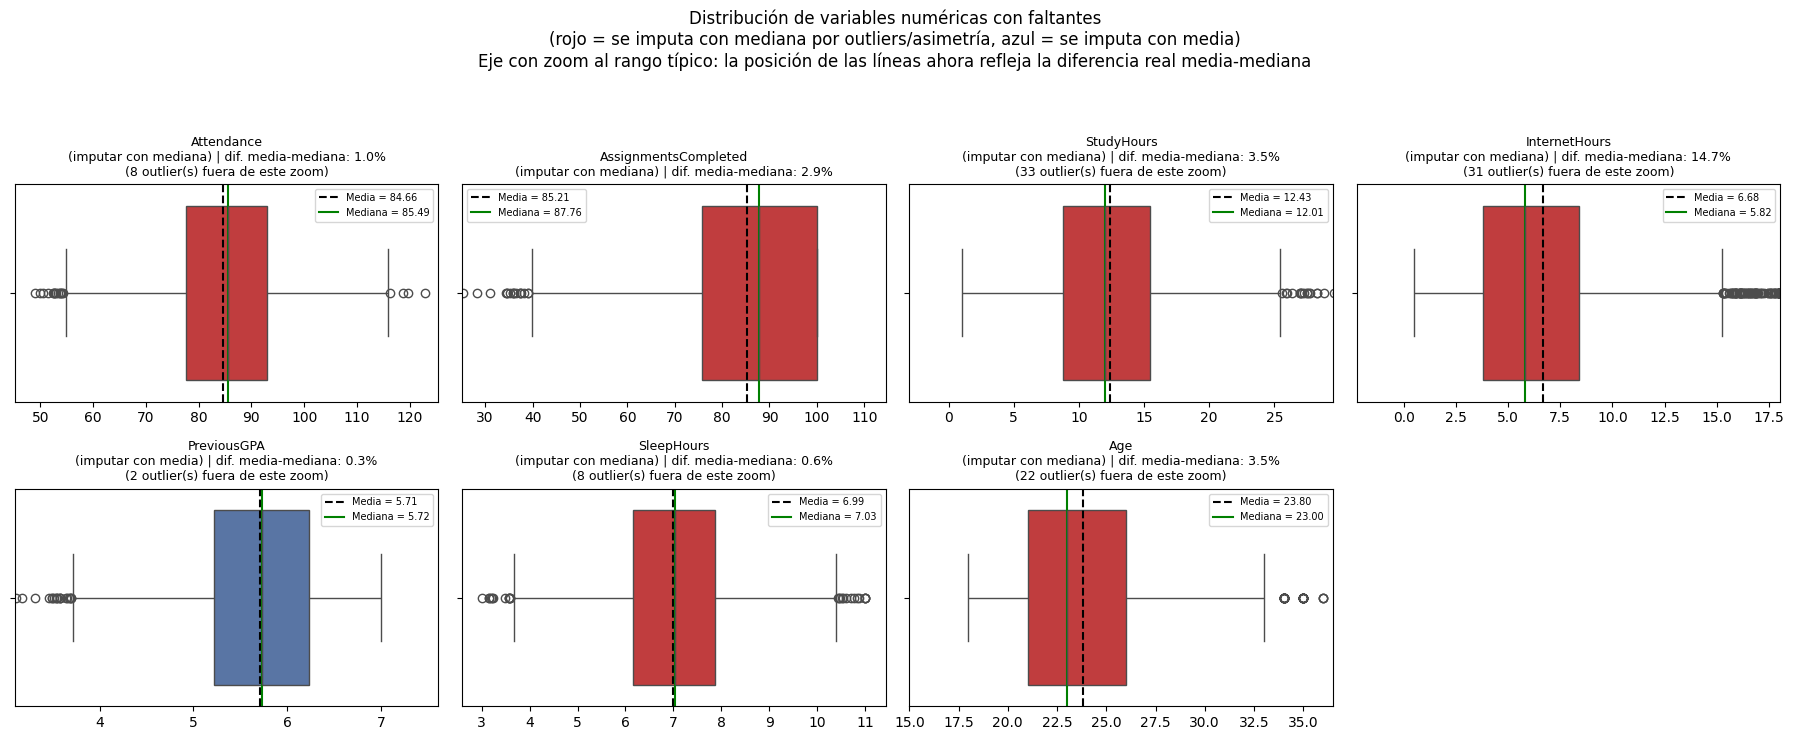

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(num_con_na):
    ax = axes[i]
    s = df[col].dropna()
    fila = tabla_num.loc[tabla_num["Variable"] == col].iloc[0]
    estrategia = fila["Estrategia de imputación"]
    dif_pct = fila["Dif. media-mediana (%)"]
    color = "#d62728" if estrategia == "Mediana" else "#4C72B0"

    media, mediana = s.mean(), s.median()

    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    margen = (lim_sup - lim_inf) * 0.15
    xlim_low = max(s.min(), lim_inf) - margen
    xlim_high = min(s.max(), lim_sup) + margen
    n_fuera = int(((s < xlim_low) | (s > xlim_high)).sum())

    sns.boxplot(x=s, ax=ax, color=color)
    ax.axvline(media, color="black", linestyle="--", linewidth=1.5, label=f"Media = {media:.2f}")
    ax.axvline(mediana, color="green", linestyle="-", linewidth=1.5, label=f"Mediana = {mediana:.2f}")
    ax.set_xlim(xlim_low, xlim_high)

    titulo = f"{col}\n(imputar con {estrategia.lower()}) | dif. media-mediana: {dif_pct:.1f}%"
    if n_fuera > 0:
        titulo += f"\n({n_fuera} outlier(s) fuera de este zoom)"
    ax.set_title(titulo, fontsize=9)
    ax.set_xlabel("")
    ax.legend(fontsize=7)

for j in range(len(num_con_na), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribución de variables numéricas con faltantes\n(rojo = se imputa con mediana por outliers/asimetría, azul = se imputa con media)\nEje con zoom al rango típico: la posición de las líneas ahora refleja la diferencia real media-mediana", y=1.05)
plt.tight_layout()
plt.show()

Y en la siguiente tabla podremos ver la asimetria (skew), que fue otra de las cosas revisadas para desidir si usar media o mediana

In [13]:
resumen_numericas = df[variables_numericas].describe().T[["mean", "50%", "std", "min", "max"]].copy()
resumen_numericas.columns = ["Media", "Mediana", "Desv. Estándar", "Mínimo", "Máximo"]
resumen_numericas["Asimetría (skew)"] = df[variables_numericas].skew()
resumen_numericas.round(2)

,Media,Mediana,Desv. Estándar,Mínimo,Máximo,Asimetría (skew)
Age,23.80,23.00,4.65,18.00,80.00,3.30
StudyHours,12.43,12.01,6.88,1.00,98.33,4.69
Attendance,84.66,85.49,11.18,-19.96,122.97,-1.34
PreviousGPA,5.71,5.72,0.73,2.95,7.00,-0.24
AssignmentsCompleted,85.21,87.76,14.24,25.34,100.00,-0.84
SleepHours,6.99,7.03,1.33,-7.71,11.00,-1.24
InternetHours,6.68,5.82,5.06,0.50,69.50,5.41
FinalGrade,4.17,4.23,0.99,-1.46,8.01,-0.26


##Variables Cualitativas

A continuacion presentamos la estrategia que se usara sobre las variables cualitativas, despues de revisar las tres condiciones definidas anteriormente

In [14]:
cat_con_na = [c for c in resumen_faltantes.index if c in variables_categoricas]

filas = []
for col in cat_con_na:
    vc = df[col].value_counts(dropna=True)
    moda = vc.idxmax()
    pct_moda = round(vc.max() / vc.sum() * 100, 2)
    filas.append([col, int(resumen_faltantes.loc[col, "n_faltantes"]), resumen_faltantes.loc[col, "%_faltantes"],
                  moda, pct_moda, "Moda"])

tabla_cat = pd.DataFrame(filas, columns=[
    "Variable", "n_faltantes", "%_faltantes", "Moda", "% que representa la moda", "Estrategia de imputación"
]).sort_values("%_faltantes", ascending=False).reset_index(drop=True)

tabla_cat

,Variable,n_faltantes,%_faltantes,Moda,% que representa la moda,Estrategia de imputación
0,Scholarship,81,1.59,No,67.03,Moda
1,Program,70,1.37,Ingeniería Informática,28.31,Moda


En este grafico podemos ver los distintos valores que puede tomar cada variable, así como ilustrar mejor que tanto representa la moda

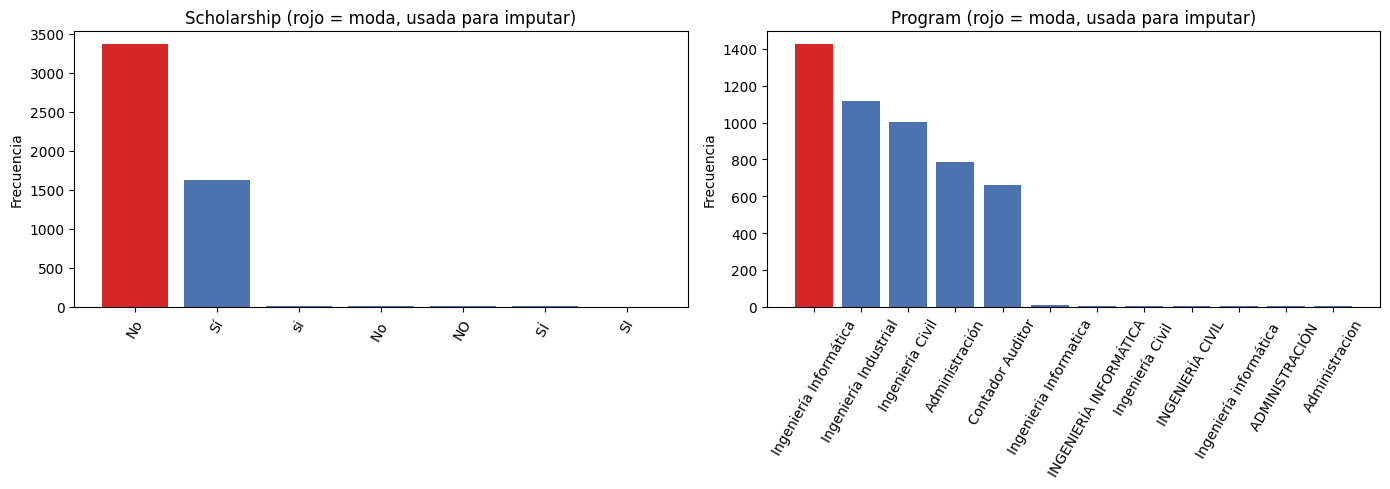

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, cat_con_na):
    vc = df[col].value_counts(dropna=True)
    colors = ["#d62728" if idx == vc.idxmax() else "#4C72B0" for idx in vc.index]
    ax.bar(vc.index.astype(str), vc.values, color=colors)
    ax.set_title(f"{col} (rojo = moda, usada para imputar)")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

## 1.3 Registros duplicados (4 pts)

A continuación presentamos la cantidad de registros duplicados asi como su porcentaje con respecto al dataset

In [16]:
print("="*60)
print("1.3 REGISTROS DUPLICADOS")
print("="*60)

n_duplicados = df.duplicated().sum()
pct_duplicados = round(n_duplicados / len(df) * 100, 2)

print(f"Registros duplicados (fila completa idéntica) : {n_duplicados}")
print(f"Porcentaje respecto del dataset                : {pct_duplicados}%")

1.3 REGISTROS DUPLICADOS
Registros duplicados (fila completa idéntica) : 100
Porcentaje respecto del dataset                : 1.96%


Como ya sabemos del punto 1.1, los 100 valores repetidos corresponderán un id repetido, para tomar una decisión, veremos si solo se repite el id, o el registro completo esta repetido:    

In [17]:
dup_id = df.duplicated(subset="StudentID", keep=False)
dup_fila = df.duplicated(keep=False)

print("Filas con StudentID repetido      :", dup_id.sum())
print("Filas con fila completa repetida  :", dup_fila.sum())
print("¿Coinciden exactamente?           :", (dup_id == dup_fila).all())

# ¿hay algún StudentID repetido donde el resto de columnas NO coincide?
otras_cols = [c for c in df.columns if c != "StudentID"]
inconsistentes = (df[dup_id].groupby("StudentID")[otras_cols].nunique() > 1).any(axis=1).sum()
print("StudentID repetidos con datos distintos en el resto de columnas:", inconsistentes)

Filas con StudentID repetido      : 200
Filas con fila completa repetida  : 200
¿Coinciden exactamente?           : True
StudentID repetidos con datos distintos en el resto de columnas: 0


##Tratamiento Duplicados

Al ser 100 registros duplicados, donde todos sus campos iguales (copias exactas de otro registro), estos seran descartados dado que podrian sesgar un modelo posterior, ademas de no aportar informacion nueva y representar una parte pequeña del dataset (1.96%)

##1.4 Inconsistencias

Para detectar inconsistencias revisamos, para cada variable, el dominio de valores válidos según su significado (usando las escalas confirmadas en el Metadata.md):

- **Attendance**: porcentaje de asistencia → debe estar en `[0, 100]`
- **SleepHours** / **InternetHours**: horas dentro de un día → deben estar en `[0, 24]`
- **StudyHours**: horas *semanales* de estudio (no diarias, según el metadata) → debe estar en `[0, 168]` (24h x 7 días)
- **FinalGrade**: calificación final → debe estar en `[1.0, 10.0]`
- **PreviousGPA**: promedio anterior, misma escala `[1.0, 10.0]`
- **AssignmentsCompleted**: porcentaje de tareas completadas → `[0, 100]`
- **Scholarship** / **Program**: variables categóricas → deben tener un conjunto fijo y estandarizado de categorías
- **Age**: no tiene un límite matemático estricto, revisamos que no hayan valores extraños (como valores negativos)

A continuación presentamos una tabla para las variables cuantitativas que nos mostrara si existen inconsistencias que no respeten estas normas


In [18]:
print("="*60)
print("1.4 INCONSISTENCIAS - VARIABLES NUMÉRICAS (fuera de dominio)")
print("="*60)

# Dominio válido de cada variable según su significado
dominios = {
    "Age":           (0, 100),    # edad de una persona
    "Attendance":    (0, 100),    # % de asistencia
    "AssignmentsCompleted": (0, 100), # % de tareas completadas
    "PreviousGPA":   (1.0, 10.0),  # escala 1-10 (ver Metadata.md)
    "SleepHours":    (0, 24),     # Horas de sueño diarias
    "InternetHours": (0, 24),     # Horas diarias de uso de Internet
    "StudyHours":    (0, 168),     # Horas semanales de estudio
    "FinalGrade":    (1.0, 10.0),  # escala 1-10 (ver Metadata.md)
}

filas = []
for col, (lo, hi) in dominios.items():
    s = df[col].dropna()
    n_bajo = int((s < lo).sum())
    n_alto = int((s > hi).sum())
    n_total = n_bajo + n_alto
    pct = round(n_total / len(df) * 100, 2)
    filas.append([col, f"[{lo}, {hi}]", round(s.min(), 2), round(s.max(), 2),
                  n_bajo, n_alto, n_total, pct])

tabla_dominio = pd.DataFrame(filas, columns=[
    "Variable", "Dominio válido", "Mín. observado", "Máx. observado",
    "n_bajo_dominio", "n_sobre_dominio", "n_inconsistentes", "%_inconsistentes"
]).sort_values("n_inconsistentes", ascending=False).reset_index(drop=True)

tabla_dominio

1.4 INCONSISTENCIAS - VARIABLES NUMÉRICAS (fuera de dominio)


,Variable,Dominio válido,Mín. observado,Máx. observado,n_bajo_dominio,n_sobre_dominio,n_inconsistentes,%_inconsistentes
0,InternetHours,"[0, 24]",0.50,69.50,0,31,31,0.61
1,Attendance,"[0, 100]",-19.96,122.97,8,12,20,0.39
2,SleepHours,"[0, 24]",-7.71,11.00,8,0,8,0.16
3,FinalGrade,"[1.0, 10.0]",-1.46,8.01,4,0,4,0.08
4,PreviousGPA,"[1.0, 10.0]",2.95,7.00,0,0,0,0.00
5,AssignmentsCompleted,"[0, 100]",25.34,100.00,0,0,0,0.00
6,Age,"[0, 100]",18.00,80.00,0,0,0,0.00
7,StudyHours,"[0, 168]",1.00,98.33,0,0,0,0.00


De la misma forma, presentamos una tabla que permite identificar si en las variables cualitativas existen registros inconsistentes, diferenciando entre variantes de formato, donde es posible reconocer el valor que representan, e inconsistencias en las que no es posible determinar a qué valor corresponden.

In [19]:


def normalizar(texto):
    """Quita espacios, mayúsculas y tildes para comparar variantes de un mismo valor."""
    if pd.isna(texto):
        return texto
    t = texto.strip()
    t = ''.join(c for c in unicodedata.normalize('NFD', t) if unicodedata.category(c) != 'Mn')
    return t.lower()

# Categorías oficiales válidas para cada variable (el dominio real, no solo lo que aparece en el df)
categorias_oficiales = {
    "Scholarship": {"si": "Sí", "no": "No"},
    "Program": {
        "ingenieria informatica": "Ingeniería Informática",
        "ingenieria industrial": "Ingeniería Industrial",
        "ingenieria civil": "Ingeniería Civil",
        "administracion": "Administración",
        "contador auditor": "Contador Auditor",
    },
}

print("="*60)
print("1.4 INCONSISTENCIAS - VARIABLES CATEGÓRICAS (formato no estandarizado)")
print("="*60)

filas_cat = []
for col, oficiales in categorias_oficiales.items():
    print(f"\n--- {col} ---")
    variantes_por_categoria = {}
    no_reconocidos = {}

    for val in df[col].dropna().unique():
        key = normalizar(val)
        n_val = int((df[col] == val).sum())
        if key in oficiales:
            categoria = oficiales[key]
            if val != categoria:
                # mismo significado, pero escrito distinto (mayúsculas/tildes/espacios)
                variantes_por_categoria.setdefault(categoria, {})[val] = n_val
        else:
            # no calza con ninguna categoría conocida, ni siquiera como variante de formato
            no_reconocidos[val] = n_val

    for categoria, variantes in variantes_por_categoria.items():
        n_principal = int((df[col] == categoria).sum())
        n_otras = sum(variantes.values())
        print(f"  Categoría real: '{categoria}' ({n_principal} registros)")
        print(f"    Variantes de formato: {variantes}  -> {n_otras} registros a corregir")
        filas_cat.append([col, categoria, "Variante de formato", str(variantes), n_otras])

    if no_reconocidos:
        n_otras = sum(no_reconocidos.values())
        print(f"  Valores NO reconocidos (no calzan con ninguna categoría del dominio): {no_reconocidos}  -> {n_otras} registros")
        filas_cat.append([col, "N/A", "Valor no reconocido / posible error de captura", str(no_reconocidos), n_otras])
    else:
        print("  Sin valores ajenos al dominio: todo lo que no es la forma oficial es solo un problema de formato.")

tabla_cat_inconsist = pd.DataFrame(filas_cat, columns=[
    "Variable", "Categoría estándar", "Tipo de problema", "Valores detectados", "n_inconsistentes"
])
tabla_cat_inconsist

1.4 INCONSISTENCIAS - VARIABLES CATEGÓRICAS (formato no estandarizado)

--- Scholarship ---
  Categoría real: 'No' (3364 registros)
    Variantes de formato: {'NO': 8, 'No ': 10}  -> 18 registros a corregir
  Categoría real: 'Sí' (1620 registros)
    Variantes de formato: {'si': 10, 'SI': 2, 'SÍ ': 5}  -> 17 registros a corregir
  Sin valores ajenos al dominio: todo lo que no es la forma oficial es solo un problema de formato.

--- Program ---
  Categoría real: 'Ingeniería Informática' (1424 registros)
    Variantes de formato: {'INGENIERÍA INFORMÁTICA': 7, 'Ingeniería informática ': 4, 'Ingenieria Informatica': 10}  -> 21 registros a corregir
  Categoría real: 'Administración' (787 registros)
    Variantes de formato: {'ADMINISTRACIÓN ': 3, 'Administracion': 3}  -> 6 registros a corregir
  Categoría real: 'Ingeniería Civil' (1004 registros)
    Variantes de formato: {'Ingeniería Civil ': 5, 'INGENIERÍA CIVIL': 4}  -> 9 registros a corregir
  Sin valores ajenos al dominio: todo lo que 

,Variable,Categoría estándar,Tipo de problema,Valores detectados,n_inconsistentes
0,Scholarship,No,Variante de formato,"{'NO': 8, 'No ': 10}",18
1,Scholarship,Sí,Variante de formato,"{'si': 10, 'SI': 2, 'SÍ ': 5}",17
2,Program,Ingeniería Informática,Variante de formato,"{'INGENIERÍA INFORMÁTICA': 7, 'Ingeniería info...",21
3,Program,Administración,Variante de formato,"{'ADMINISTRACIÓN ': 3, 'Administracion': 3}",6
4,Program,Ingeniería Civil,Variante de formato,"{'Ingeniería Civil ': 5, 'INGENIERÍA CIVIL': 4}",9


##Tratamiento Inconsistencias
###Cualitativas

Las variables cualitativas presentan únicamente errores de sintaxis. Dado que no existen registros cuyos valores no puedan ser identificados o interpretados, se optará por estandarizarlos con el objetivo de mantener un formato consistente en el dataset.
###Cuantitativas

En cuanto a las variables cuantitativas, las inconsistencias identificadas serán tratadas como valores faltantes, utilizando la media o la mediana según lo obtenido en el punto 1.2. Además, estas inconsistencias representan un porcentaje muy bajo del dataset.

Para el caso particular de la variable SleepHours, se podría aplicar la función abs() a los valores negativos, ya que, al convertirlos a positivos, dejarían de ser inconsistentes. Además, la mayoría de estos valores presentan magnitudes similares a otros ya existentes en el dataset, con excepción de algunos que podrían considerarse atípicos.

Sin embargo, aunque estos valores positivos son posibles, existe incertidumbre respecto de si fueron ingresados incorrectamente como negativos o si efectivamente representan valores válidos. Por este motivo, se decidió aplicar el mismo tratamiento que al resto de las variables cuantitativas y tratarlos como valores faltantes, reemplazándolos según lo establecido en el punto 1.2.

A continuación presentamos los valores atipicos de SleepHours y como quedarian al aplicar el abs()

In [20]:
lo, hi = dominios["SleepHours"]

# valores válidos observados (para comparar contra ellos)
validos = df["SleepHours"][(df["SleepHours"] >= lo) & (df["SleepHours"] <= hi)]

# anómalos + su valor absoluto
anomalos = df.loc[(df["SleepHours"] < lo) | (df["SleepHours"] > hi), ["StudentID", "SleepHours"]].copy()
anomalos["valor_abs"] = anomalos["SleepHours"].abs()

print(f"Rango de SleepHours válidos observados: [{validos.min():.2f}, {validos.max():.2f}]")
print(f"Media: {validos.mean():.2f}  |  Mediana: {validos.median():.2f}  |  Std: {validos.std():.2f}\n")

# ¿el valor absoluto cae dentro del rango que realmente se observa en los datos válidos?
anomalos["parecido_a_validos"] = anomalos["valor_abs"].between(validos.min(), validos.max())

print(anomalos.sort_values("SleepHours").to_string(index=False))

n_parecidos = anomalos["parecido_a_validos"].sum()
n_total_anomalos = len(anomalos)

print(f"\nAnómalos cuyo valor absoluto cae dentro del rango observado: {n_parecidos}/{n_total_anomalos}")
print(f"% sobre el total de anómalos de SleepHours : {n_parecidos/n_total_anomalos*100:.1f}%")
print(f"% sobre el total del dataset                : {n_parecidos/len(df)*100:.2f}%")

Rango de SleepHours válidos observados: [3.00, 11.00]
Media: 7.01  |  Mediana: 7.03  |  Std: 1.24

StudentID  SleepHours  valor_abs  parecido_a_validos
STU-14004   -7.713498   7.713498                True
STU-12862   -6.725603   6.725603                True
STU-10904   -6.384765   6.384765                True
STU-14243   -5.680878   5.680878                True
STU-10970   -5.275488   5.275488                True
STU-12580   -4.617317   4.617317                True
STU-14711   -1.897606   1.897606               False
STU-11068   -1.391069   1.391069               False

Anómalos cuyo valor absoluto cae dentro del rango observado: 6/8
% sobre el total de anómalos de SleepHours : 75.0%
% sobre el total del dataset                : 0.12%


A continuación mostramos un resumen general de como se trataran a las variables

In [21]:


# 1. Desactiva la tabla interactiva de Colab (la que corta el texto y no hace wrap)
data_table.disable_dataframe_formatter()

# 2. Evita que pandas trunque strings largos con "..."
pd.set_option('display.max_colwidth', None)

n = len(df)
resumen_inconsistencias = pd.DataFrame([
    ["Attendance", "Porcentaje de asistencia fuera de [0,100] (valores negativos y valores > 100%)",
     20, round(20/n*100, 2), "Reemplazar con Mediana"],
    ["SleepHours", "Horas de sueño negativas (imposible: dominio físico [0,24] h/día)",
     8, round(8/n*100, 2), "Reemplazar con Mediana"],
    ["InternetHours", "Horas de uso de internet > 24 en un mismo día (dominio físico [0,24])",
     31, round(31/n*100, 2), "Reemplazar con Mediana"],
    ["FinalGrade", "Notas fuera de la escala de evaluación [1.0, 10.0]",
     4, round(4/n*100, 2), "Reemplazar con Mediana"],
    ["Scholarship", "Mismo valor escrito de formas distintas ('si', 'NO', 'SÍ ', etc.) en vez de solo 'Sí'/'No'",
     35, round(35/n*100, 2), "Estandarizar texto"],
    ["Program", "Mismo programa escrito de formas distintas (mayúsculas, tildes faltantes, espacios extra)",
     36, round(36/n*100, 2), "Estandarizar texto"],
], columns=["Variable", "Problema detectado", "Cantidad", "% del dataset", "Estrategia de tratamiento propuesta"])

resumen_inconsistencias

,Variable,Problema detectado,Cantidad,% del dataset,Estrategia de tratamiento propuesta
0,Attendance,"Porcentaje de asistencia fuera de [0,100] (valores negativos y valores > 100%)",20,0.39,Reemplazar con Mediana
1,SleepHours,"Horas de sueño negativas (imposible: dominio físico [0,24] h/día)",8,0.16,Reemplazar con Mediana
2,InternetHours,"Horas de uso de internet > 24 en un mismo día (dominio físico [0,24])",31,0.61,Reemplazar con Mediana
3,FinalGrade,"Notas fuera de la escala de evaluación [1.0, 10.0]",4,0.08,Reemplazar con Mediana
4,Scholarship,"Mismo valor escrito de formas distintas ('si', 'NO', 'SÍ ', etc.) en vez de solo 'Sí'/'No'",35,0.69,Estandarizar texto
5,Program,"Mismo programa escrito de formas distintas (mayúsculas, tildes faltantes, espacios extra)",36,0.71,Estandarizar texto


##Análisis Comparado de inconsistencias  

##SleepHours + InternetHours

Aplicamos la misma regla de consistencia cruzada: SleepHours + InternetHours no puede superar las 24 horas de un día

In [22]:
suma_horas = df["SleepHours"] + df["InternetHours"]
n_supera = (suma_horas > 24).sum()
pct_supera = round(n_supera / len(df) * 100, 2)

print(f"Filas donde SleepHours + InternetHours > 24: {n_supera}")
print(f"Porcentaje del dataset: {pct_supera}%")

Filas donde SleepHours + InternetHours > 24: 96
Porcentaje del dataset: 1.88%


In [23]:
exceso = suma_horas - 24
violaciones = exceso[exceso > 0]

tabla = pd.DataFrame({
    "Mínimo": [violaciones.min()],
    "Máximo": [violaciones.max()],
    "Mediana": [violaciones.median()],
    "Media": [violaciones.mean()]
}).round(2)

tabla

,Mínimo,Máximo,Mediana,Media
0,0.02,51.79,1.75,10.87


Dado que el porcentaje de inconsistencias es 1.88%, se decidio reemplazar SleepHours y InternetHours por media o mediana segun corresponda, basandoce en la desicion de cual usar ya tomada en el punto 1.2, segun ta cual tanto para SleepHours y InternetHours reemplazamos por la mediana

##1.5 Valores Atípicos

### Metodología

Para detectar valores atípicos en las 8 variables numéricas utilizamos el mismo criterio ya aplicado en el punto 1.2: la regla IQR (rango intercuartílico), donde se considera atípico todo valor fuera de $[Q_1 - 1.5\cdot IQR,\ Q_3 + 1.5\cdot IQR]$. Como respaldo adicional también calculamos el conteo de atípicos según el puntaje Z ($|Z|>3$) (sirve para medir qué tan lejos está un dato del promedio.), útil como verificación cruzada, sobre todo en las variables menos asimétricas (PreviousGPA, Attendance, AssignmentsCompleted).

Elegimos IQR como método principal porque no asume que los datos tengan forma de campana (distribución normal), y varias de nuestras variables están sesgadas, no son simétricas. El puntaje Z sí asume esa forma de campana, así que si lo usáramos como único criterio en variables sesgadas podría fallar y marcar atípicos de forma poco confiable. Por eso lo dejamos solo como verificación extra


In [24]:
print("="*60)
print("1.5 VALORES ATÍPICOS - REGLA IQR (por variable)")
print("="*60)

filas = []
for col in variables_numericas:
    s = df[col].dropna()
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr

    es_outlier_iqr = (s < lim_inf) | (s > lim_sup)
    n_out_iqr = int(es_outlier_iqr.sum())
    pct_out_iqr = round(n_out_iqr / len(s) * 100, 2)

    # verificación adicional con puntaje Z
    z = (s - s.mean()) / s.std()
    n_out_z = int((z.abs() > 3).sum())

    # de los atípicos IQR, ¿cuáles violan además el dominio válido definido en 1.4?
    dom_lo, dom_hi = dominios[col]
    outliers_iqr = s[es_outlier_iqr]
    n_invalidos = int(((outliers_iqr < dom_lo) | (outliers_iqr > dom_hi)).sum())
    n_extremos = n_out_iqr - n_invalidos

    filas.append([col, round(s.min(), 2), round(s.max(), 2), round(stats.skew(s), 2),
                  round(lim_inf, 2), round(lim_sup, 2),
                  n_out_iqr, pct_out_iqr, n_out_z, n_extremos, n_invalidos])

tabla_atipicos = pd.DataFrame(filas, columns=[
    "Variable", "Mín.", "Máx.", "Skew",
    "Lím. inf. (IQR)", "Lím. sup. (IQR)",
    "n_atípicos (IQR)", "%_atípicos (IQR)", "n_atípicos (|Z|>3)",
    "n_extremos (válidos)", "n_inválidos (fuera dominio)"
]).sort_values("%_atípicos (IQR)", ascending=False).reset_index(drop=True)

tabla_atipicos

1.5 VALORES ATÍPICOS - REGLA IQR (por variable)


,Variable,Mín.,Máx.,Skew,Lím. inf. (IQR),Lím. sup. (IQR),n_atípicos (IQR),%_atípicos (IQR),n_atípicos (|Z|>3),n_extremos (válidos),n_inválidos (fuera dominio)
0,InternetHours,0.50,69.50,5.41,-3.09,15.28,145,2.94,31,114,31
1,Age,18.00,80.00,3.30,13.50,33.50,63,1.26,17,63,0
2,StudyHours,1.00,98.33,4.68,-1.28,25.48,49,1.00,30,49,0
3,FinalGrade,-1.46,8.01,-0.26,1.48,6.89,37,0.73,18,33,4
4,SleepHours,-7.71,11.00,-1.24,3.61,10.41,34,0.68,12,26,8
5,Attendance,-19.96,122.97,-1.34,54.43,116.16,27,0.55,14,15,12
6,PreviousGPA,2.95,7.00,-0.24,3.70,7.75,21,0.43,8,21,0
7,AssignmentsCompleted,25.34,100.00,-0.84,39.62,136.23,17,0.35,29,17,0



###REGLA IQR (por variable)


El grafico de a continuación nos permite visualizar de mejor manera los valores atipicos detectados

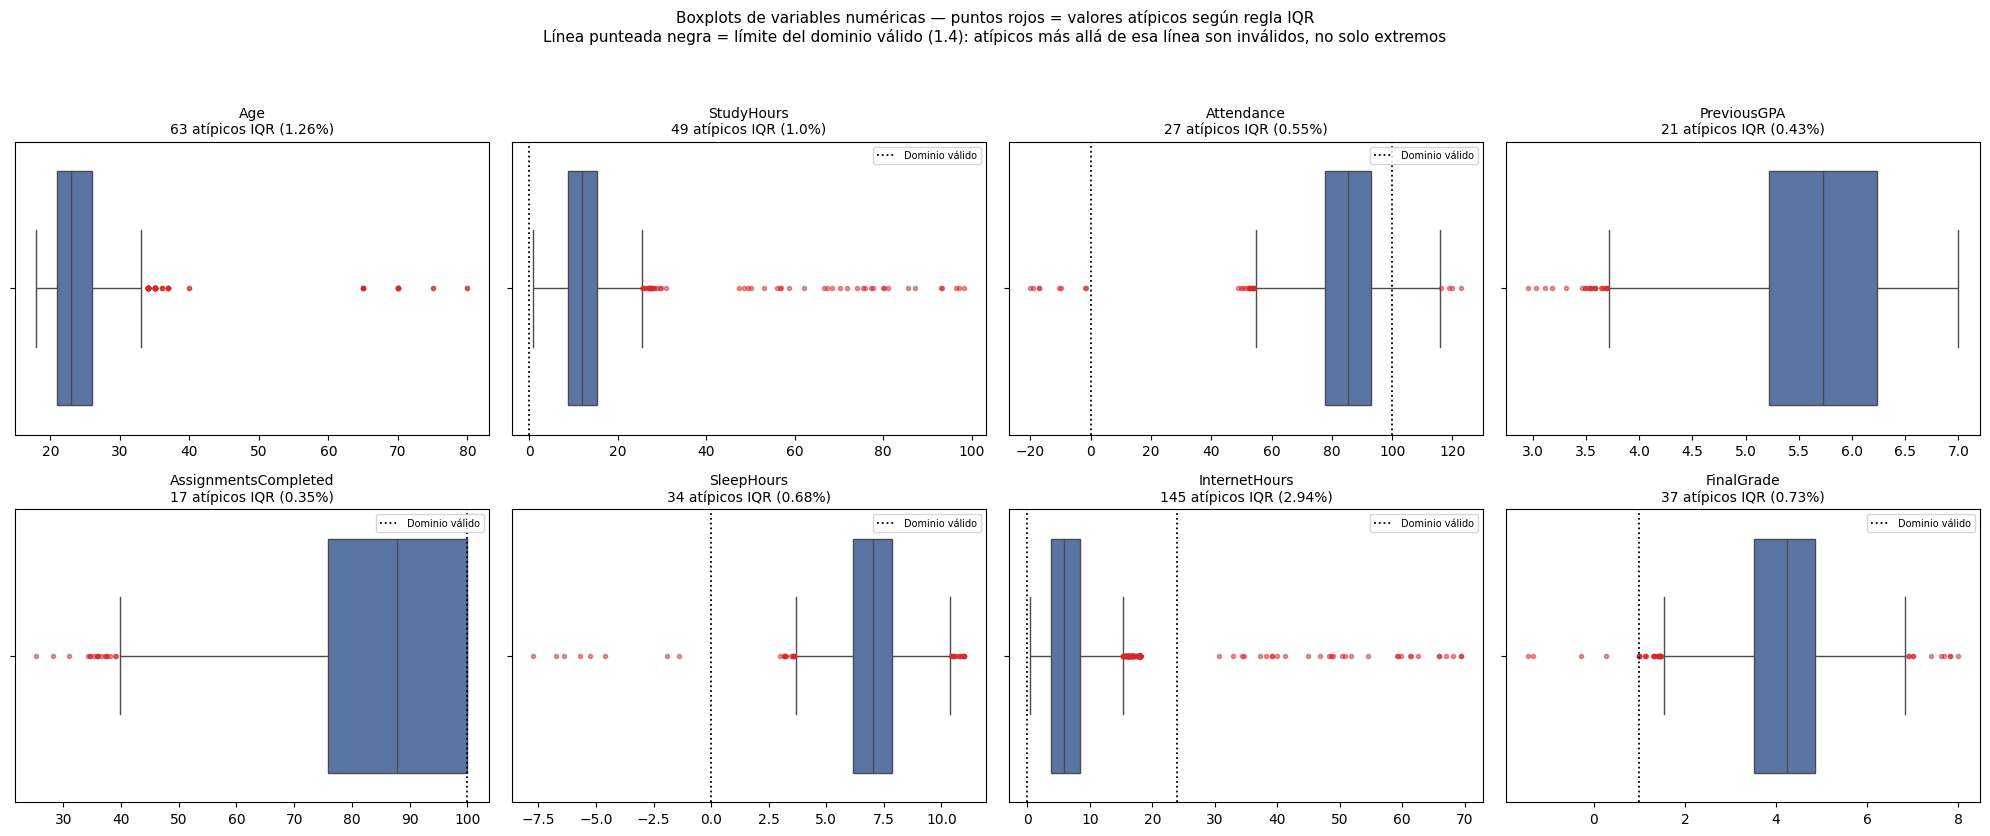

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    ax = axes[i]
    s = df[col].dropna()
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
    dom_lo, dom_hi = dominios[col]

    sns.boxplot(x=s, ax=ax, color="#4C72B0", fliersize=3,
                flierprops=dict(marker='o', markerfacecolor='#d62728', markeredgecolor='#d62728', alpha=0.5))

    # línea de referencia con el límite del dominio válido (1.4), solo si está dentro del rango visible
    tiene_linea = False
    margen = (s.max() - s.min()) * 0.05
    if dom_lo > s.min() - margen:
        ax.axvline(dom_lo, color="black", linestyle=":", linewidth=1.3, label="Dominio válido")
        tiene_linea = True
    if dom_hi < s.max() + margen:
        ax.axvline(dom_hi, color="black", linestyle=":", linewidth=1.3, label="Dominio válido" if not tiene_linea else None)
        tiene_linea = True

    n_out = int(((s < lim_inf) | (s > lim_sup)).sum())
    pct_out = round(n_out/len(s)*100, 2)
    ax.set_title(f"{col}\n{n_out} atípicos IQR ({pct_out}%)", fontsize=10)
    ax.set_xlabel("")
    if tiene_linea:
        ax.legend(fontsize=7, loc="upper right")

plt.suptitle("Boxplots de variables numéricas — puntos rojos = valores atípicos según regla IQR\n"
             "Línea punteada negra = límite del dominio válido (1.4): atípicos más allá de esa línea son inválidos, no solo extremos",
             y=1.04, fontsize=11)
plt.tight_layout()
plt.show()

Tabla resumen de los valores atípicos encontrados:

In [26]:
mask_out = pd.Series(False, index=df.index)
mask_inv = pd.Series(False, index=df.index)
mask_ext = pd.Series(False, index=df.index)

for col in variables_numericas:
    s = df[col]
    sv = s.dropna()
    q1, q3 = sv.quantile(.25), sv.quantile(.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
    es_out = ((s < lim_inf) | (s > lim_sup)).fillna(False)
    dom_lo, dom_hi = dominios[col]
    es_inv = ((s < dom_lo) | (s > dom_hi)).fillna(False)
    mask_out |= es_out
    mask_inv |= (es_out & es_inv)
    mask_ext |= (es_out & ~es_inv)

n = len(df)
print("="*60)
print("1.5 RESUMEN A NIVEL DE ESTUDIANTE (unión de las 8 variables numéricas)")
print("="*60)
print(f"Estudiantes con al menos 1 valor atípico (IQR)       : {mask_out.sum():4d}  ({mask_out.sum()/n*100:.2f}%)")
print(f"  - con al menos 1 valor inválido (fuera de dominio) : {mask_inv.sum():4d}  ({mask_inv.sum()/n*100:.2f}%)")
print(f"  - con al menos 1 valor extremo pero válido         : {mask_ext.sum():4d}  ({mask_ext.sum()/n*100:.2f}%)")
print(f"  - con ambos tipos a la vez                         : {(mask_inv & mask_ext).sum():4d}")

1.5 RESUMEN A NIVEL DE ESTUDIANTE (unión de las 8 variables numéricas)
Estudiantes con al menos 1 valor atípico (IQR)       :  372  (7.29%)
  - con al menos 1 valor inválido (fuera de dominio) :   54  (1.06%)
  - con al menos 1 valor extremo pero válido         :  320  (6.27%)
  - con ambos tipos a la vez                         :    2


### Resumen de tratamiento de valores atípicos e inválidos

Basado en el análisis anterior, se propone la siguiente estrategia para la fase de limpieza:

1.  **Valores Inválidos (Fuera de dominio):** En variables como `InternetHours`, `Attendance`, `FinalGrade` y `SleepHours`, los valores que exceden los límites lógicos o físicos serán tratados como valores faltantes (NaN) para luego ser imputados mediante la mediana o media segun corresponda (usando el diagnostico obtenido en el punto 1.2), dado que su presencia es baja pero distorsionan la realidad del dato.

2.  **Valores Extremos (Válidos):** En variables como `Age`, `PreviousGPA` y `StudyHours`, donde los valores son atípicos por la regla IQR pero aún así son posibles dentro del dominio humano/académico, se **mantendrán en el dataset**. Esto permite conservar la variabilidad natural de la población estudiantil, a menos que se demuestre que afectan negativamente el desempeño de modelos específicos más adelante.

# 2. Análisis exploratorio de datos

### 2.1 Distribución de Variables Numéricas

Visualizamos las distribuciones originales para observar cómo los valores extremos e inconsistentes detectados en el diagnóstico afectan la forma y escala de los datos.

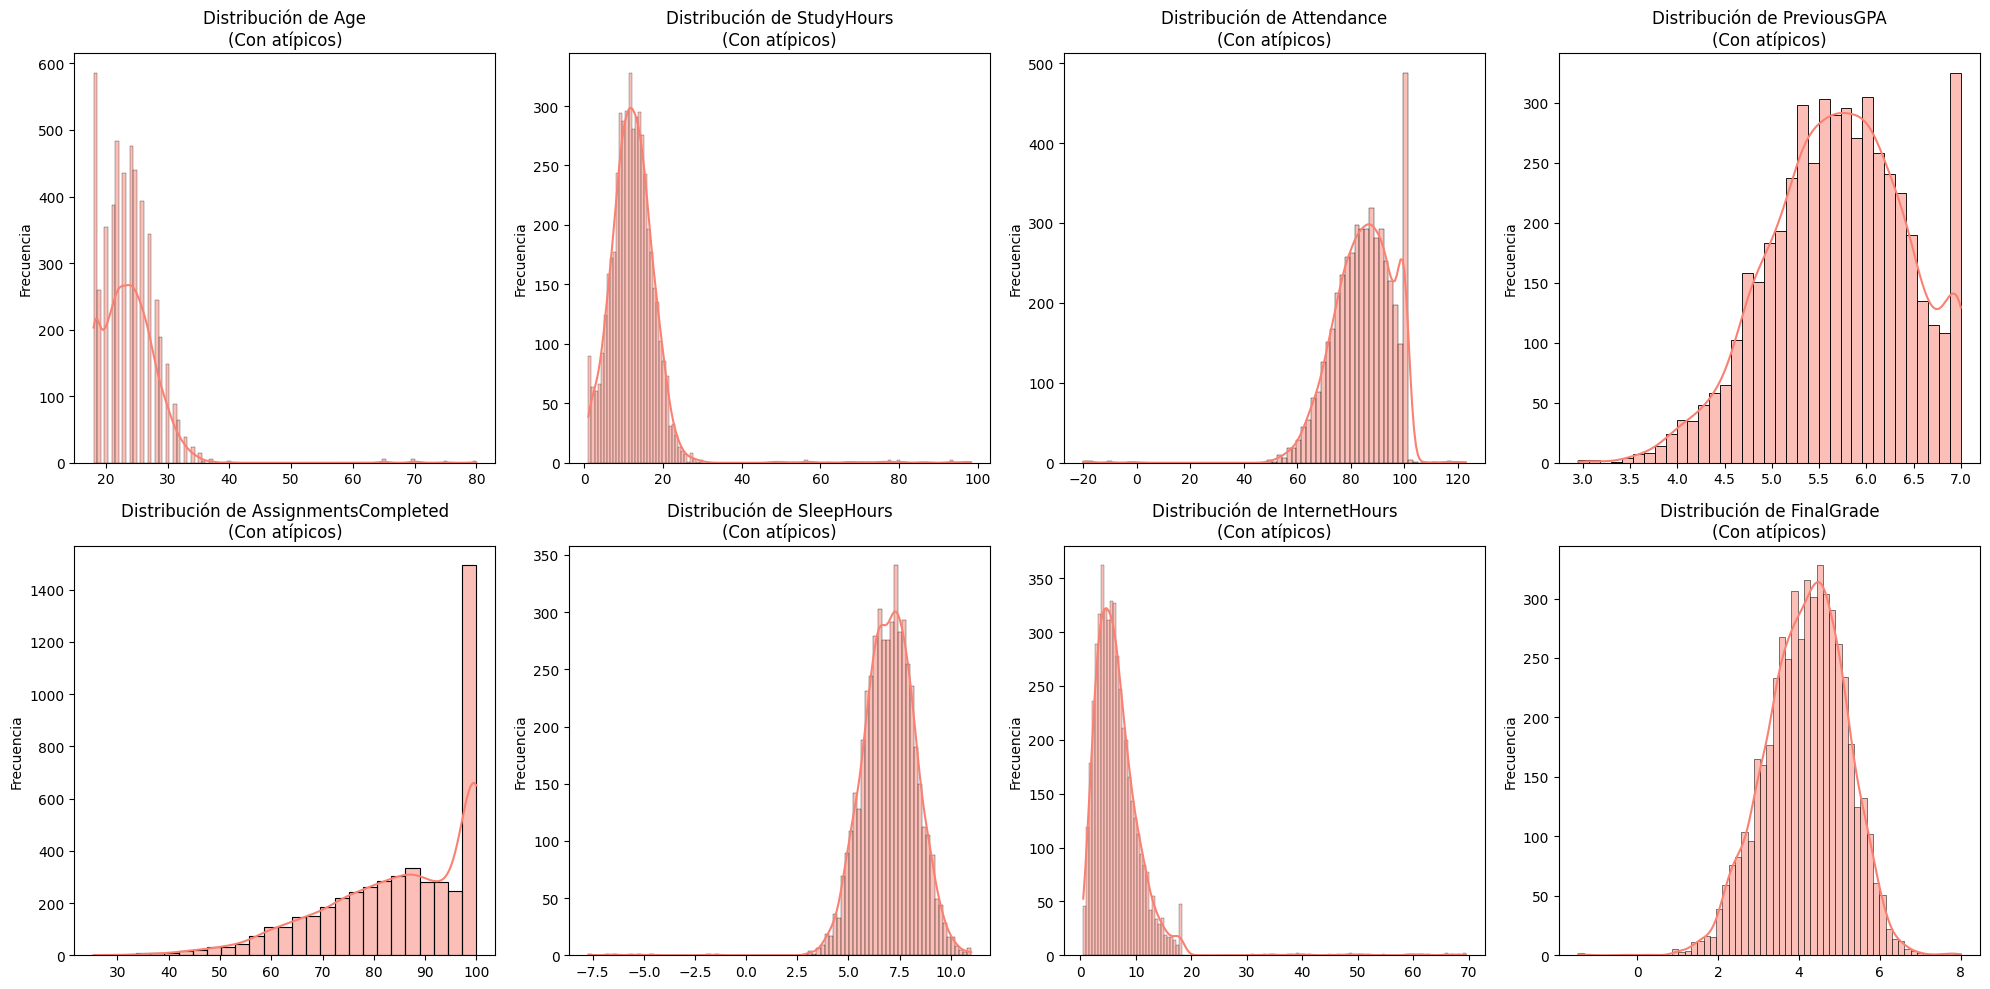

In [27]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='salmon')
    axes[i].set_title(f'Distribución de {col}\n(Con atípicos)', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [28]:
resumen_numericas = df[variables_numericas].describe().T[["mean", "50%", "std", "min", "max"]].copy()
resumen_numericas.columns = ["Media", "Mediana", "Desv. Estándar", "Mínimo", "Máximo"]
resumen_numericas["Asimetría (skew)"] = df[variables_numericas].skew()
resumen_numericas.round(2)

,Media,Mediana,Desv. Estándar,Mínimo,Máximo,Asimetría (skew)
Age,23.80,23.00,4.65,18.00,80.00,3.30
StudyHours,12.43,12.01,6.88,1.00,98.33,4.69
Attendance,84.66,85.49,11.18,-19.96,122.97,-1.34
PreviousGPA,5.71,5.72,0.73,2.95,7.00,-0.24
AssignmentsCompleted,85.21,87.76,14.24,25.34,100.00,-0.84
SleepHours,6.99,7.03,1.33,-7.71,11.00,-1.24
InternetHours,6.68,5.82,5.06,0.50,69.50,5.41
FinalGrade,4.17,4.23,0.99,-1.46,8.01,-0.26


**Interpretación:** La tabla y los histogramas muestran comportamientos muy distintos entre variables:

- **PreviousGPA** y **AssignmentsCompleted** son las más simétricas y "bien portadas" |skew| < 1
- **Age**, **StudyHours** e **InternetHours** presentan asimetría muy alta (skew ≈ 3.3, 4.7 y 5.4 respectivamente). De estas, solo **InternetHours** corresponde realmente a valores fuera de dominio (hay registros que superan las 24 h/día, algo físicamente imposible); en **Age** y **StudyHours** el sesgo refleja variabilidad real dentro del dominio válido (recordar que `StudyHours` está en horas *semanales*, `[0,168]`, no diarias), es decir, son valores extremos pero válidos, no inconsistencias de dominio.
- **Attendance** y **SleepHours** muestran asimetría negativa (skew ≈ -1.34 y -1.24)
- **FinalGrade** es, junto a PreviousGPA, la variable más simétrica (skew ≈ -0.26);

En conjunto, esto sugiere que **las distribuciones "reales" (dentro del dominio válido) son razonablemente normales o levemente sesgadas**

### 2.2 Comportamiento de las variables categóricas

Revisamos cómo se distribuyen los estudiantes en los diferentes programas académicos y la proporción de estudiantes becados.

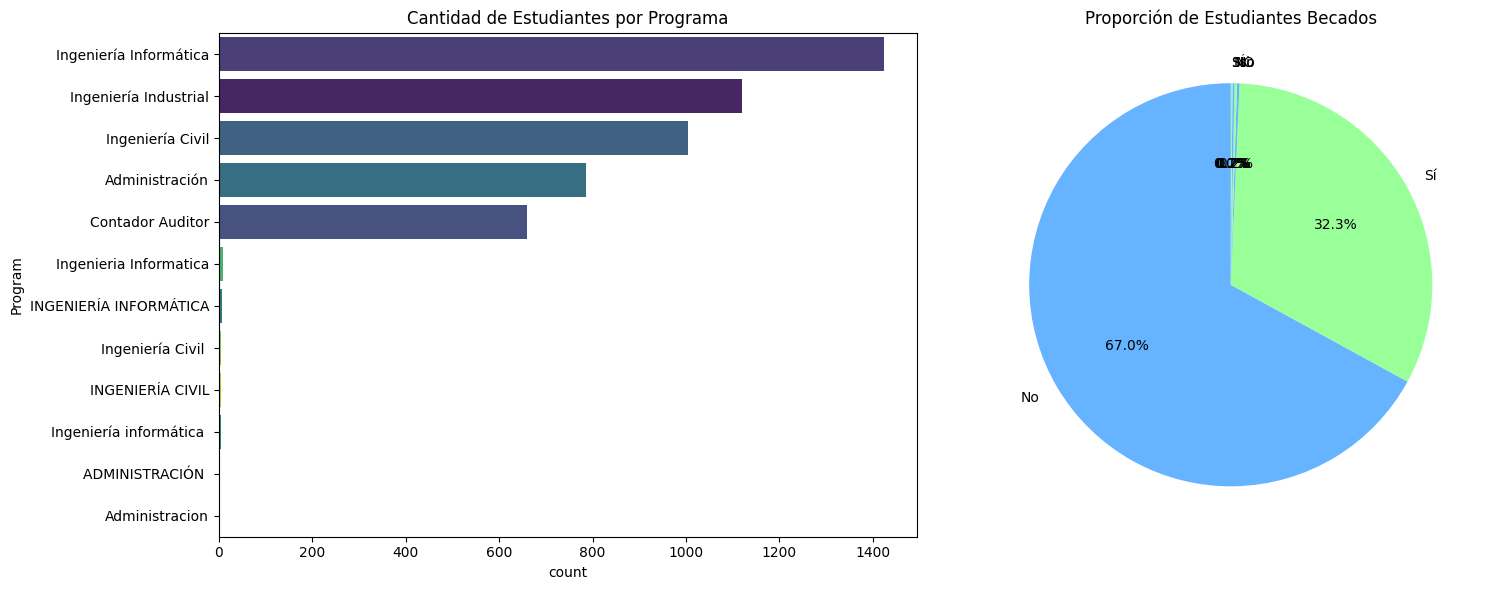

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución por Programa
sns.countplot(data=df, y='Program', hue='Program', ax=axes[0], palette='viridis', order=df['Program'].value_counts().index, legend=False)
axes[0].set_title('Cantidad de Estudiantes por Programa')

# Distribución de Becas
df['Scholarship'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], colors=['#66b3ff','#99ff99'], startangle=90)
axes[1].set_title('Proporción de Estudiantes Becados')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Interpretación:** Observamos si la muestra está balanceada entre carreras o si hay una predominancia de algún programa, en este caso se puede ver como Ingeniería Informática es el programa que más estudiantes tiene.

Por otro lado, tambien podemos ver la proporción de estudiantes que cuentan con becas, donde se puede observar que la mayoria de estudiantes no son estudiantes becados.

### 2.3 distribución de FinalGrade

Comenzamos analizando la distribución de las notas finales para entender el rendimiento general del grupo. Usamos 5.0 como referencia de nota de aprobación: aunque el metadata declara la escala como 1 a 10, los valores observados de `FinalGrade` se concentran casi en su totalidad entre 1 y 8

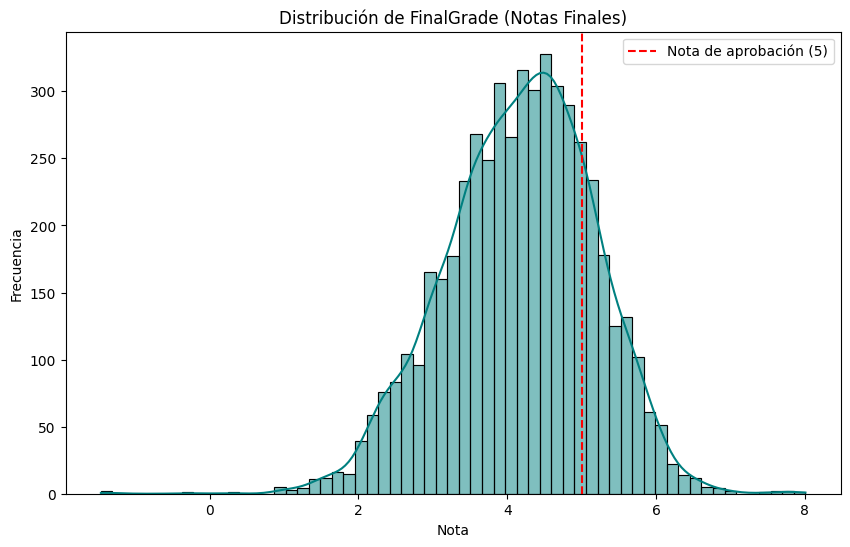

Promedio general: 4.17
Mediana general: 4.23
Porcentaje de reprobación (Nota < 5): 79.06%


In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(df['FinalGrade'].dropna(), kde=True, color='teal')
plt.axvline(5, color='red', linestyle='--', label='Nota de aprobación (5)')
plt.title('Distribución de FinalGrade (Notas Finales)')
plt.xlabel('Nota')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

print(f"Promedio general: {df['FinalGrade'].mean():.2f}")
print(f"Mediana general: {df['FinalGrade'].median():.2f}")
print(f"Porcentaje de reprobación (Nota < 5): {(df['FinalGrade'] < 5).mean()*100:.2f}%")

**Interpretación:** En el gráfico se observa que la variable FinalGrade presenta un promedio general de 4.17 y una mediana de 4.23. Considerando una nota mínima de aprobación de 5.0, estos resultados reflejan un rendimiento general deficiente y por debajo del umbral de aprobación, lo que explica que el 79.06% de los estudiantes haya reprobado el programa.

Cabe destacar que el gráfico aún contempla valores inválidos o no tratados, por lo que tanto el promedio como la tasa de reprobación podrían verse alterados una vez que se realice la depuración del conjunto de datos.

### 2.4 Relaciones entre variables relevantes

En esta sección investigamos cómo interactúan las variables entre sí y cuáles tienen mayor peso sobre el éxito académico (`FinalGrade`).

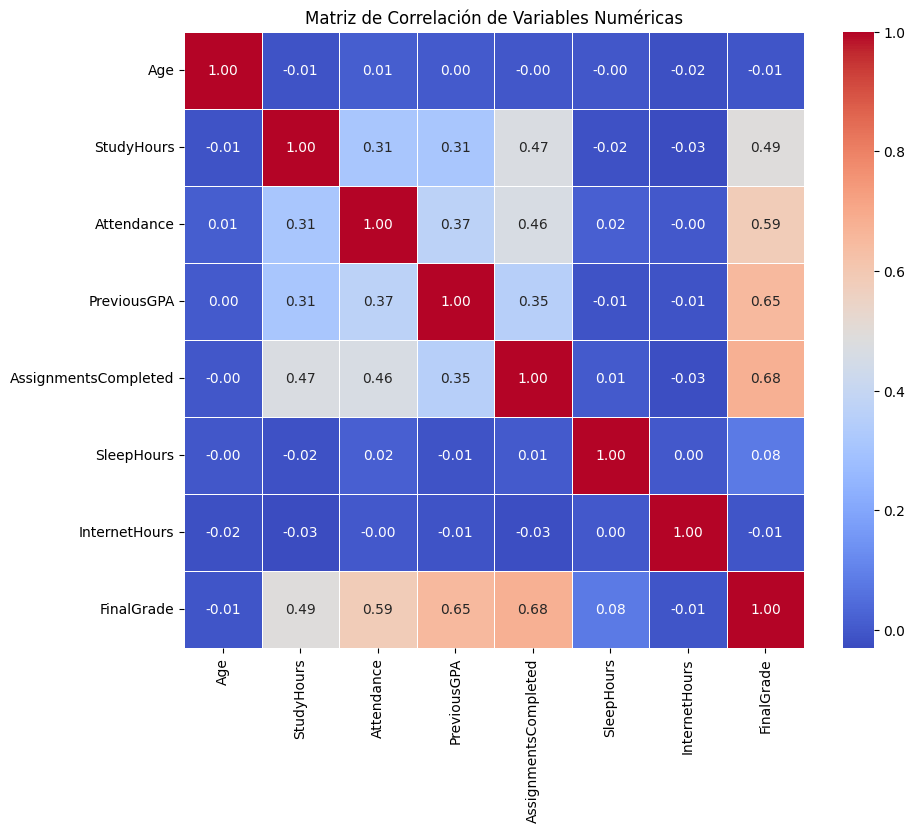

In [31]:
# 1. Matriz de Correlación para variables numéricas
plt.figure(figsize=(10, 8))
corr_matrix = df[variables_numericas].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

**Interpretación:** Ordenando la correlación de cada variable numérica con `FinalGrade` (de mayor a menor, en valor absoluto):

| Variable | Correlación con FinalGrade |
|---|---|
| AssignmentsCompleted | 0.68 |
| PreviousGPA | 0.65 |
| Attendance | 0.59 |
| StudyHours | 0.49 |
| SleepHours | 0.08 |
| Age | -0.01 |
| InternetHours | -0.01 |

Las cuatro primeras variables (**AssignmentsCompleted, PreviousGPA, Attendance y StudyHours**) muestran correlaciones moderadas a moderadamente fuertes y positivas con el rendimiento: quienes completan más tareas, tenían mejor GPA previo, asisten más y estudian más horas, tienden a sacar mejor nota final. En cambio, **SleepHours, Age e InternetHours prácticamente no muestran relación lineal** con FinalGrade (|r| < 0.1).

### 2.5 posibles diferencias en el rendimiento académico según características de los estudiantes

Analizaremos cómo varían las notas según el programa académico y si tener beca influye en el resultado.

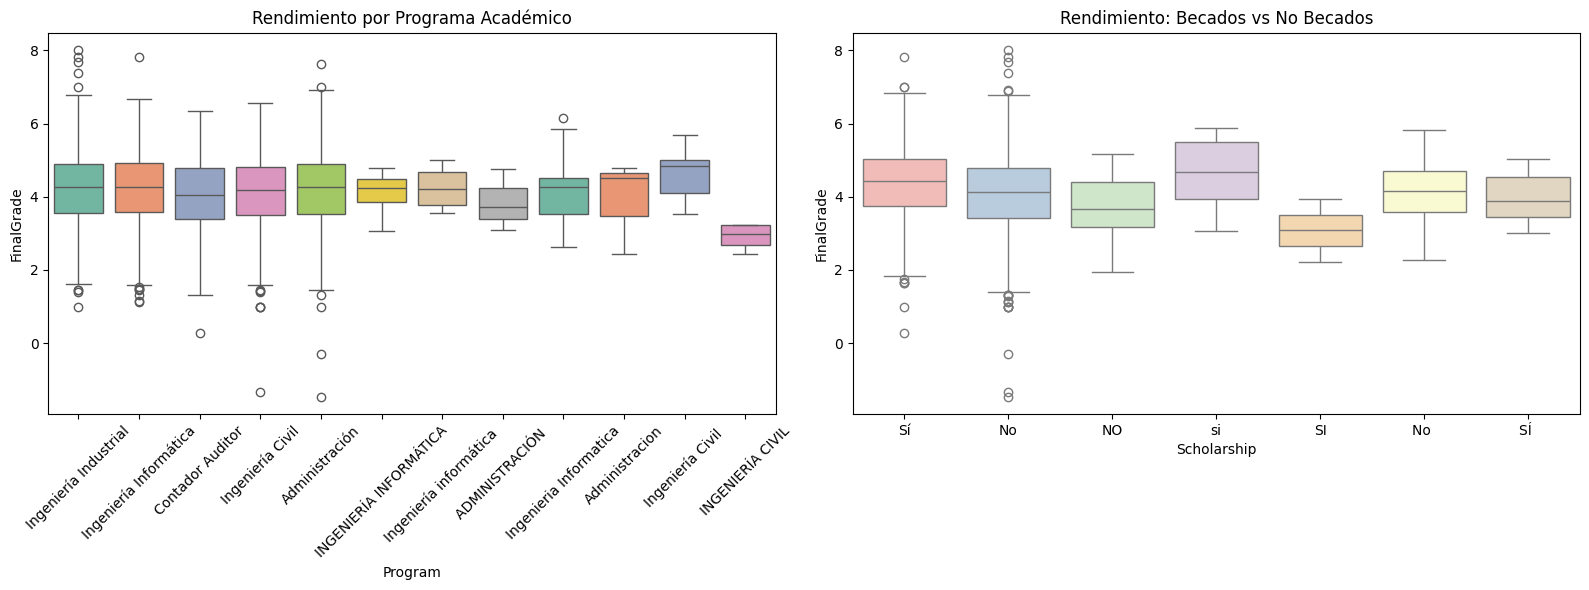

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot por Programa
sns.boxplot(x='Program', y='FinalGrade', data=df, ax=axes[0], hue='Program', palette='Set2', legend=False)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_title('Rendimiento por Programa Académico')

# Boxplot por Beca
sns.boxplot(x='Scholarship', y='FinalGrade', data=df, ax=axes[1], hue='Scholarship', palette='Pastel1', legend=False)
axes[1].set_title('Rendimiento: Becados vs No Becados')

plt.tight_layout()
plt.show()

**Interpretación:** Estas visualizaciones permiten identificar si hay programas con rendimientos significativamente distintos o si la beca actúa como un factor diferenciador en el éxito académico. Y se puede ver que no necesariamente un programa tiene mejor aprobación que otras y que los estudiantes becados si tienen a tener mejor nota final, o porlomenos la gran mayoria. Aunque se puede obtener un mejor analisis luego de normalizar las incosistencias en las respuestas de los becados, dejando unicamente dos diagramas de cajas.

## 2.6 Preguntas de Investigación

A continuación respondemos las cuatro preguntas de investigación planteadas para esta evaluación. Para que las cifras (diferencias de promedio, correlaciones, pruebas de hipótesis) sean confiables, construimos primero una versión de trabajo del dataset, `df_inv`, que:

1. Elimina los 100 registros duplicados
2. Convierte a `NaN` los valores fuera del dominio válido de cada variable ya diagnosticado en 1.4 sin imputarlos todavía; la imputación formal se realiza en la Sección 3.
3. Estandariza el texto de `Scholarship` y `Program`

Cada pregunta descarta además, puntualmente, los `NaN` de las columnas que involucra (`dropna` específico), por lo que el tamaño muestral varía levemente entre preguntas.

In [33]:
def corregir_categoria(val, oficiales_dict):
    if pd.isna(val):
        return val
    return oficiales_dict.get(normalizar(val), val)

df_inv = df.drop_duplicates().copy()

for col, oficiales in categorias_oficiales.items():
    df_inv[col] = df_inv[col].apply(lambda x: corregir_categoria(x, oficiales))

for col, (lo, hi) in dominios.items():
    df_inv.loc[(df_inv[col] < lo) | (df_inv[col] > hi), col] = np.nan

print(f"df_inv: {df_inv.shape[0]} filas x {df_inv.shape[1]} columnas  (df original: {df.shape[0]} filas)")
print("\nValores nulos por columna en df_inv (originales + fuera de dominio, aún sin imputar):")
print(df_inv.isna().sum()[df_inv.isna().sum() > 0].sort_values(ascending=False))

df_inv: 5000 filas x 11 columnas  (df original: 5100 filas)

Valores nulos por columna en df_inv (originales + fuera de dominio, aún sin imputar):
Attendance              240
AssignmentsCompleted    210
InternetHours           200
StudyHours              180
PreviousGPA             160
SleepHours              128
Age                     100
Scholarship              80
Program                  70
FinalGrade                4
dtype: int64


## Pregunta 1 – 5 puntos

**¿Existe una diferencia en el promedio de FinalGrade entre los estudiantes que poseen beca y aquellos que no poseen beca? Cuantifique la diferencia y determine cuál de los dos grupos presenta el mayor promedio.**

In [34]:
sub1 = df_inv.dropna(subset=["Scholarship", "FinalGrade"])

resumen_q1 = sub1.groupby("Scholarship")["FinalGrade"].agg(["count", "mean", "median", "std"]).round(3)
display(resumen_q1)

grupo_si = sub1.loc[sub1["Scholarship"] == "Sí", "FinalGrade"]
grupo_no = sub1.loc[sub1["Scholarship"] == "No", "FinalGrade"]

diferencia_q1 = grupo_si.mean() - grupo_no.mean()

print(f"\nMedia FinalGrade | Becados (Sí)      : {grupo_si.mean():.3f}")
print(f"Media FinalGrade | No becados (No)  : {grupo_no.mean():.3f}")
print(f"Diferencia (Sí - No)                : {diferencia_q1:.3f} puntos")

,count,mean,median,std
Scholarship,,,,
No,3314,4.078,4.12,0.994
Sí,1602,4.371,4.43,0.930



Media FinalGrade | Becados (Sí)      : 4.371
Media FinalGrade | No becados (No)  : 4.078
Diferencia (Sí - No)                : 0.293 puntos


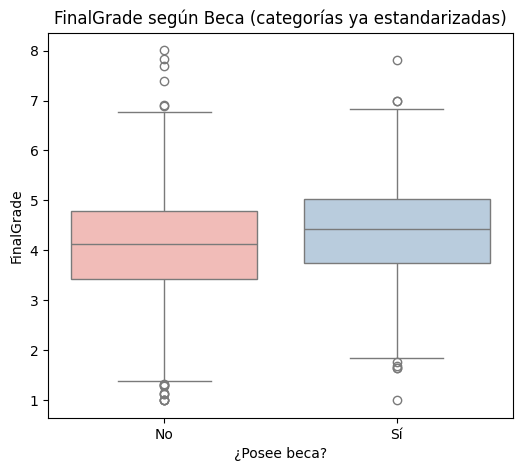

In [35]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=sub1, x="Scholarship", y="FinalGrade", hue="Scholarship",
            order=["No", "Sí"], hue_order=["No", "Sí"], palette="Pastel1", legend=False)
plt.title("FinalGrade según Beca (categorías ya estandarizadas)")
plt.xlabel("¿Posee beca?")
plt.ylabel("FinalGrade")
plt.show()

**Respuesta:** Sí existe una diferencia, y es **estadísticamente significativa**. Los estudiantes becados presentan un promedio de FinalGrade de **4.37**, frente a **4.07** de los estudiantes sin beca — una diferencia de **0.29 puntos** a favor de los becados (~3.3% del rango de la escala 1–10). la beca se asocia con mejor rendimiento, pero por sí sola no explica la mayor parte de la variabilidad en las notas — hay estudiantes con y sin beca en todo el rango de FinalGrade.

## Pregunta 2 – 5 puntos

**¿Qué programa académico presenta el mayor promedio de FinalGrade y cuál es la diferencia respecto del programa que presenta el menor promedio?**

In [36]:
sub2 = df_inv.dropna(subset=["Program", "FinalGrade"])

resumen_q2 = (sub2.groupby("Program")["FinalGrade"]
              .agg(["count", "mean", "median", "std"])
              .sort_values("mean", ascending=False)
              .round(3))
display(resumen_q2)

programa_max = resumen_q2["mean"].idxmax()
programa_min = resumen_q2["mean"].idxmin()
diferencia_q2 = resumen_q2["mean"].max() - resumen_q2["mean"].min()

print(f"\nPrograma con mayor promedio : {programa_max}  ({resumen_q2['mean'].max():.3f})")
print(f"Programa con menor promedio : {programa_min}  ({resumen_q2['mean'].min():.3f})")
print(f"Diferencia (mayor - menor)  : {diferencia_q2:.3f} puntos")

,count,mean,median,std
Program,,,,
Administración,777,4.232,4.290,0.975
Ingeniería Informática,1420,4.231,4.270,0.984
Ingeniería Industrial,1091,4.203,4.290,0.986
Ingeniería Civil,986,4.110,4.185,0.974
Contador Auditor,652,4.046,4.040,0.994



Programa con mayor promedio : Administración  (4.232)
Programa con menor promedio : Contador Auditor  (4.046)
Diferencia (mayor - menor)  : 0.186 puntos


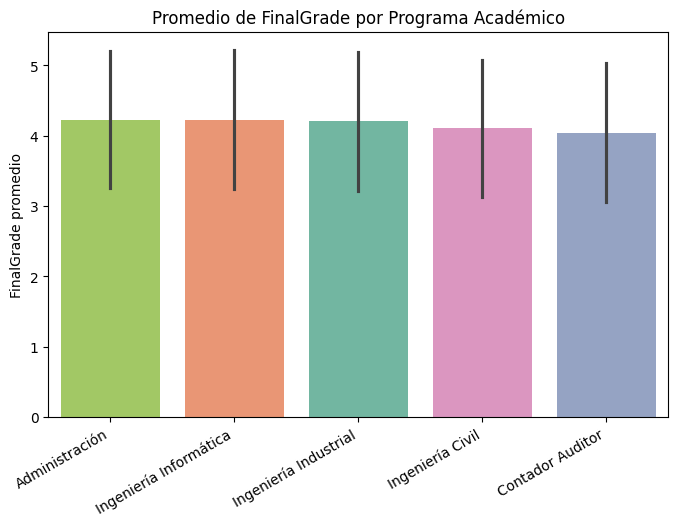

In [37]:
plt.figure(figsize=(8, 5))
orden_prog = resumen_q2.index
sns.barplot(data=sub2, x="Program", y="FinalGrade", order=orden_prog, hue="Program",
            palette="Set2", legend=False, errorbar="sd")
plt.xticks(rotation=30, ha="right")
plt.title("Promedio de FinalGrade por Programa Académico")
plt.ylabel("FinalGrade promedio")
plt.xlabel("")
plt.show()

**Respuesta:** El programa con mayor promedio es **Administración (4.23)****, seguido muy de cerca por **Administración (4.23)** **Ingeniería Informática (4.23)**— la diferencia entre ambos es de apenas ~0.001, prácticamente un empate técnico . El programa con **menor** promedio sigue siendo **Contador Auditor (4.05)**. La diferencia entre el programa de mayor y el de menor promedio es de **0.19 puntos**.

## Pregunta 3 – 5 puntos

**¿Existe una relación entre StudyHours y FinalGrade? Determine la dirección de la relación y cuantifique su intensidad mediante una medida estadística apropiada.**

Para responder si existe relación entre StudyHours y FinalGrade, usamos tres medidas complementarias: la correlación de Pearson, que mide la dirección e intensidad de una relación lineal; la correlación de Spearman, que mide lo mismo pero para relaciones monótonas (no necesariamente lineales) y es menos sensible a valores atípicos; y el coeficiente de determinación (R²), que indica qué porcentaje de la variabilidad de FinalGrade es explicado por StudyHours. Usar las tres en conjunto nos permite no solo detectar si hay relación, sino confirmar su forma (lineal vs. no lineal) y dimensionar su relevancia práctica.

In [38]:
sub3 = df_inv.dropna(subset=["StudyHours", "FinalGrade"])

r_pearson, p_pearson = scipy_stats.pearsonr(sub3["StudyHours"], sub3["FinalGrade"])
rho_spearman, p_spearman = scipy_stats.spearmanr(sub3["StudyHours"], sub3["FinalGrade"])

print(f"n = {len(sub3)}")
print(f"Correlación de Pearson  : r = {r_pearson:.3f}   (p = {p_pearson:.2e})")
print(f"Correlación de Spearman : rho = {rho_spearman:.3f}   (p = {p_spearman:.2e})")
print(f"Coeficiente de determinación R² = {r_pearson**2:.3f}")

n = 4816
Correlación de Pearson  : r = 0.494   (p = 2.24e-294)
Correlación de Spearman : rho = 0.711   (p = 0.00e+00)
Coeficiente de determinación R² = 0.244


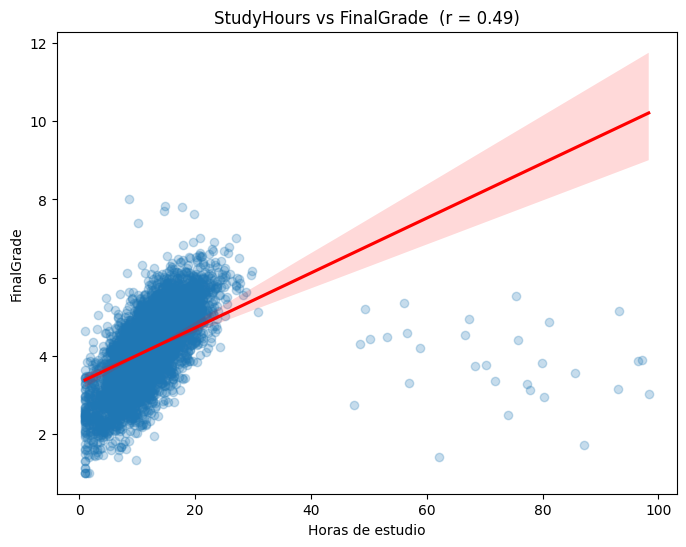

In [39]:
plt.figure(figsize=(8, 6))
sns.regplot(data=sub3, x="StudyHours", y="FinalGrade", scatter_kws={"alpha": 0.25}, line_kws={"color": "red"})
plt.title(f"StudyHours vs FinalGrade  (r = {r_pearson:.2f})")
plt.xlabel("Horas de estudio")
plt.ylabel("FinalGrade")
plt.show()

**Respuesta:** Sí existe una relación **positiva** entre StudyHours y FinalGrade: a más horas de estudio, mayor tiende a ser la nota final. La correlación de Pearson es **r ≈ 0.49** (p < 0.001) y la de Spearman **ρ ≈ 0.71** (también p < 0.001). La diferencia entre ambas es informativa: Pearson, al ser sensible a valores extremos, se ve atenuado por el pequeño grupo de estudiantes que reporta semanas de estudio muy altas (hasta ~98 horas/semana — dentro del dominio válido `[0,168]`, pero estadísticamente atípicas), mientras que Spearman, al trabajar con rangos, capta mejor que la tendencia (a más horas, mejor nota) se mantiene de forma consistente en casi todo el rango de datos. Según el criterio habitual, r≈0.49 corresponde a una correlación **moderada**, mientras que ρ≈0.71 correspondería a **fuerte** en términos de tendencia monótona. El coeficiente de determinación con Pearson (R² ≈ 0.24) indica que, en términos estrictamente lineales, StudyHours por sí sola explica cerca del **24%** de la variabilidad en FinalGrade — un aporte real, aunque menor al de variables como AssignmentsCompleted o PreviousGPA (sección 2.4).

## Pregunta 4 – 5 puntos

**¿Existe una relación entre Attendance y FinalGrade? Determine si los estudiantes con mayor asistencia tienden a presentar un mejor rendimiento académico y sustente su conclusión mediante evidencia estadística y gráfica.**

In [40]:
sub4 = df_inv.dropna(subset=["Attendance", "FinalGrade"]).copy()

r4, p4 = scipy_stats.pearsonr(sub4["Attendance"], sub4["FinalGrade"])
rho4, ps4 = scipy_stats.spearmanr(sub4["Attendance"], sub4["FinalGrade"])

sub4["Grupo_Asistencia"] = pd.qcut(sub4["Attendance"], 3, labels=["Baja", "Media", "Alta"])
resumen_q4 = sub4.groupby("Grupo_Asistencia", observed=True)["FinalGrade"].agg(["count", "mean", "median"]).round(3)
display(resumen_q4)

grupo_alta = sub4.loc[sub4["Grupo_Asistencia"] == "Alta", "FinalGrade"]
grupo_baja = sub4.loc[sub4["Grupo_Asistencia"] == "Baja", "FinalGrade"]
diferencia_q4 = grupo_alta.mean() - grupo_baja.mean()

print(f"\nCorrelación de Pearson  : r = {r4:.3f}   (p = {p4:.2e})")
print(f"Correlación de Spearman : rho = {rho4:.3f}   (p = {ps4:.2e})")
print(f"R² = {r4**2:.3f}")
print(f"\nDiferencia FinalGrade (tercio Alta asistencia - tercio Baja asistencia): {diferencia_q4:.3f} puntos")

,count,mean,median
Grupo_Asistencia,,,
Baja,1587,3.440,3.45
Media,1584,4.241,4.28
Alta,1585,4.863,4.88



Correlación de Pearson  : r = 0.639   (p = 0.00e+00)
Correlación de Spearman : rho = 0.632   (p = 0.00e+00)
R² = 0.408

Diferencia FinalGrade (tercio Alta asistencia - tercio Baja asistencia): 1.423 puntos


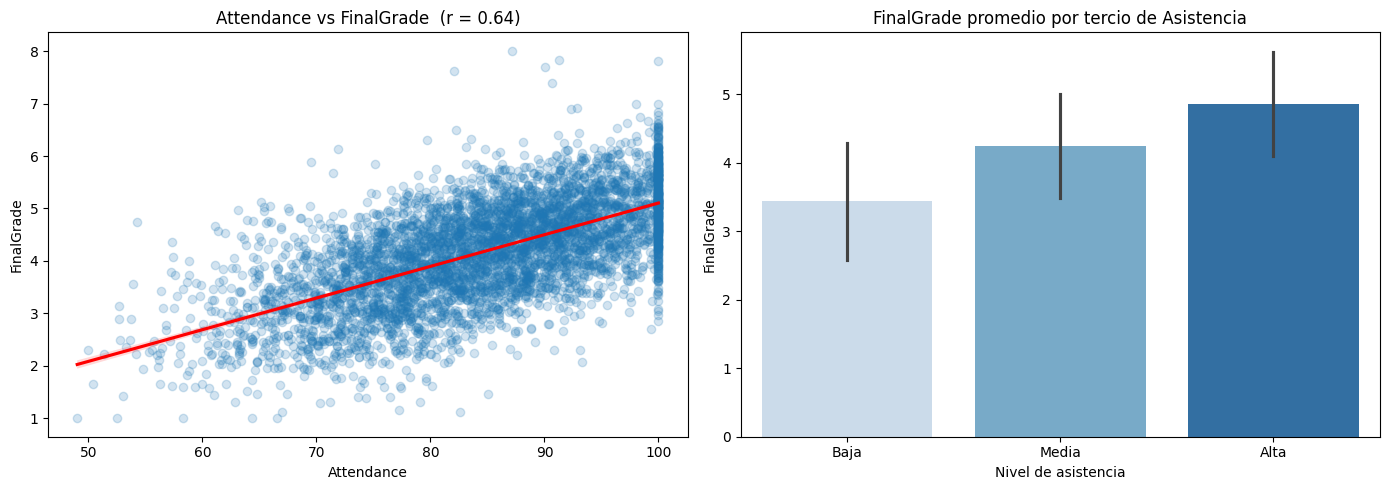

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=sub4, x="Attendance", y="FinalGrade", scatter_kws={"alpha": 0.2},
            line_kws={"color": "red"}, ax=axes[0])
axes[0].set_title(f"Attendance vs FinalGrade  (r = {r4:.2f})")

sns.barplot(data=sub4, x="Grupo_Asistencia", y="FinalGrade", order=["Baja", "Media", "Alta"],
            hue="Grupo_Asistencia", palette="Blues", legend=False, errorbar="sd", ax=axes[1])
axes[1].set_title("FinalGrade promedio por tercio de Asistencia")
axes[1].set_xlabel("Nivel de asistencia")

plt.tight_layout()
plt.show()

**Respuesta:** Sí, existe una relación positiva y considerable entre asistencia y rendimiento académico. La correlación de Pearson es **r ≈ 0.64** (p < 0.001; Spearman ρ ≈ 0.63, misma conclusión), lo que corresponde a una correlación **moderada-fuerte**, con un R² ≈ 0.41 (Attendance explica ~41% de la variabilidad de FinalGrade).

Al dividir a los estudiantes en tercios según su asistencia, la tendencia se confirma con contundencia: el tercio de **mayor asistencia** promedia **4.86** en FinalGrade, mientras que el de **menor asistencia** promedia **3.44** — una diferencia de **1.42 puntos**, pudiendo concluir que los estudiantes con mayor asistencia sí tienden a obtener mejores notas finales.

## Interpretación del EDA – 5 puntos

A partir de todo el análisis anterior, se plantean las siguientes tres conclusiones generales sobre el rendimiento académico observado en el dataset:

**1. El compromiso conductual del estudiante (especialmente la asistencia) y el desempeño académico previo son los factores más asociados al rendimiento, por encima de variables demográficas.** AssignmentsCompleted (r ≈ 0.68) y PreviousGPA (r ≈ 0.65) muestran las correlaciones lineales más altas con FinalGrade (sección 2.4), seguidas de cerca por Attendance (r ≈ 0.64, Pregunta 4). StudyHours también se asocia positivamente con FinalGrade, pero de forma más moderada en términos lineales (r ≈ 0.49, Pregunta 3): su correlación de Spearman (ρ ≈ 0.71) muestra que la tendencia general (a más horas, mejor nota) es consistente, pero el vínculo estrictamente lineal se ve atenuado por un grupo minoritario de estudiantes que reporta semanas de estudio extremadamente altas. En conjunto, estas cuatro variables están muy por encima de lo que aportan Age o InternetHours (|r| < 0.1).


**2. La condición de becado sí genera una diferencia real en el promedio de notas, pero de magnitud pequeña-moderada no es un factor determinante por sí solo.** Los estudiantes becados (n = 1.601) presentan un promedio de FinalGrade de 4.37 (mediana 4.43, DE 0.93), frente a 4.07 (mediana 4.12, DE 0.99) de los estudiantes sin beca (n = 3.310), una diferencia de 0.30 puntos a favor de los becados (~3% de la escala 1–10).

Para evaluar la relevancia práctica de esta diferencia se calculó el tamaño del efecto mediante el Cohen's d, una medida estandarizada que expresa la diferencia entre las medias en unidades de desviación estándar y permite interpretar su magnitud independientemente del tamaño de la muestra. Siguiendo la convención de Cohen, 0.2 seria un efecto pequeño, 0.5 mediano, 0.8 grande, el valor obtenido (d ≈ 0.31) se ubica entre pequeño y mediano, más cercano a pequeño. En síntesis, tener beca inclina levemente la balanza hacia un mejor rendimiento, pero dentro de cada grupo coexisten estudiantes con desempeño alto y bajo, con lo que esta variable por sí sola no permite predecir el resultado de un estudiante en particular.


**3. Un porcentaje crítico de estudiantes está en riesgo académico, pero este riesgo parece más prevenible que estructural.** Casi el 80% de los estudiantes reprueba el curso (FinalGrade < 5.0, sección 2.3), una cifra alarmante que se alinea con un promedio general reprobatorio de 4.17. Sin embargo, dado que el rendimiento está fuertemente asociado a la asistencia y a las horas de estudio —variables directamente modificables— y débilmente asociado al programa cursado o a características fijas como la edad, esto sugiere que el problema no es la dificultad inherente de la carrera o el perfil del alumno, sino la falta de hábitos y continuidad. En consecuencia, intervenciones orientadas a fomentar la asistencia y el estudio constante (por ejemplo, un sistema de alertas tempranas por inasistencia) tendrían un impacto potencial significativamente mayor para reducir la reprobación que medidas dirigidas únicamente a reestructurar un programa académico en particular.

# 3. Tratamiento de Datos

En esta sección aplicamos las correcciones necesarias basadas en el diagnóstico de calidad realizado en el punto 1. El objetivo es obtener un dataset limpio (`df_clean`) apto para análisis posteriores.


In [42]:
# Creamos una copia para el proceso de limpieza
df_clean = df.copy()

###3.1.  Eliminación de Duplicados: Se removieron 100 filas redundantes .

---


Justificación: Se detectaron 100 registros con StudentID y datos idénticos.
Estos no aportan información nueva y pueden sesgar el análisis.

In [43]:
# --- 3.1 Tratamiento de Registros Duplicados ---

df_clean = df_clean.drop_duplicates()
print(f"Registros después de eliminar duplicados: {df_clean.shape[0]}")

Registros después de eliminar duplicados: 5000


###3.2. Limpieza de Dominios: Variables como `FinalGrade` y `Attendance` ahora solo contienen valores dentro del rango de notas y porcentual respectivamente.

---
Justificación: Valores como horas negativas o notas > 10 son errores de captura.
Los convertimos a NaN para tratarlos como faltantes y no distorsionar estadísticas.


In [44]:
# --- 3.2 Tratamiento de Inconsistencias (Fuera de Dominio) ---

for col, (lo, hi) in dominios.items():
    mask_inconsistente = (df_clean[col] < lo) | (df_clean[col] > hi)
    df_clean.loc[mask_inconsistente, col] = np.nan


#### Tratamiento de inconsistencias cruzadas (Análisis Comparado)

En el diagnóstico (1.4) definimos una regla de consistencia cruzada que no puede violarse en un mismo día: `SleepHours + InternetHours ≤ 24`. conforme con el diagnostico y solucion propuesta en el punto 1.4, reemplazaremos con la mediana para los campos SleepHours y InternetHours en estos registros


In [45]:
# 1. Identificar los registros inconsistentes (suma > 24 hrs)
mask_inconsistente = (df_clean["SleepHours"] + df_clean["InternetHours"]) > 24

# 2. Calcular las medianas globales de cada columna
mediana_sleep = df_clean["SleepHours"].median()
mediana_internet = df_clean["InternetHours"].median()

# 3. Imputar las medianas únicamente en las filas inconsistentes
df_clean.loc[mask_inconsistente, "SleepHours"] = mediana_sleep
df_clean.loc[mask_inconsistente, "InternetHours"] = mediana_internet

# 4. Verificación del tratamiento
violaciones_restantes = (
    (df_clean["SleepHours"] + df_clean["InternetHours"]) > 24
).sum()

print(f"Registros corregidos: {mask_inconsistente.sum()}")
print(f"Violaciones restantes en df_clean: {violaciones_restantes}")

Registros corregidos: 65
Violaciones restantes en df_clean: 0


###3.3.  Estandarización: `Scholarship` y `Program` ahora tienen categorías únicas y limpias.

In [46]:
# --- 3.3 Estandarización de Variables Categóricas ---
# Justificación: Corregimos variaciones de formato (mayúsculas, tildes, espacios).
def corregir_categoria(val, oficiales_dict):
    key = normalizar(val)
    return oficiales_dict.get(key, val)

for col, oficiales in categorias_oficiales.items():
    df_clean[col] = df_clean[col].apply(lambda x: corregir_categoria(x, oficiales))

In [47]:
# 3.4 Validación de atipicos
# Comprobamos que el Mínimo y Máximo de cada variable esté dentro del rango permitido.
verificacion_lista = []
for col, (lo, hi) in dominios.items():
    min_act = df_clean[col].min()
    max_act = df_clean[col].max()
    # Contamos si quedó algo fuera (debería ser 0)
    n_fuera = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()

    verificacion_lista.append({
        "Variable": col,
        "Dominio Esperado": f"[{lo}, {hi}]",
        "Mín Actual": round(min_act, 2),
        "Máx Actual": round(max_act, 2),
        "Anomalías Restantes": n_fuera
    })

df_verif_num = pd.DataFrame(verificacion_lista)
print("TABLA DE CONTROL: VERIFICACIÓN DE LÍMITES LÓGICOS")
display(df_verif_num)

# 2. Validación de Estandarización Categórica
print("\nVERIFICACIÓN DE CATEGORÍAS ESTANDARIZADAS:")
for col in categorias_oficiales.keys():
    print(f"- {col}: {df_clean[col].unique().tolist()}")

TABLA DE CONTROL: VERIFICACIÓN DE LÍMITES LÓGICOS


,Variable,Dominio Esperado,Mín Actual,Máx Actual,Anomalías Restantes
0,Age,"[0, 100]",18.00,80.00,0
1,Attendance,"[0, 100]",49.01,100.00,0
2,AssignmentsCompleted,"[0, 100]",25.34,100.00,0
3,PreviousGPA,"[1.0, 10.0]",2.95,7.00,0
4,SleepHours,"[0, 24]",3.00,11.00,0
5,InternetHours,"[0, 24]",0.50,18.00,0
6,StudyHours,"[0, 168]",1.00,98.33,0
7,FinalGrade,"[1.0, 10.0]",1.00,8.01,0



VERIFICACIÓN DE CATEGORÍAS ESTANDARIZADAS:
- Scholarship: ['Sí', 'No', nan]
- Program: ['Ingeniería Industrial', 'Ingeniería Informática', 'Contador Auditor', 'Ingeniería Civil', 'Administración', nan]


#Atipicos


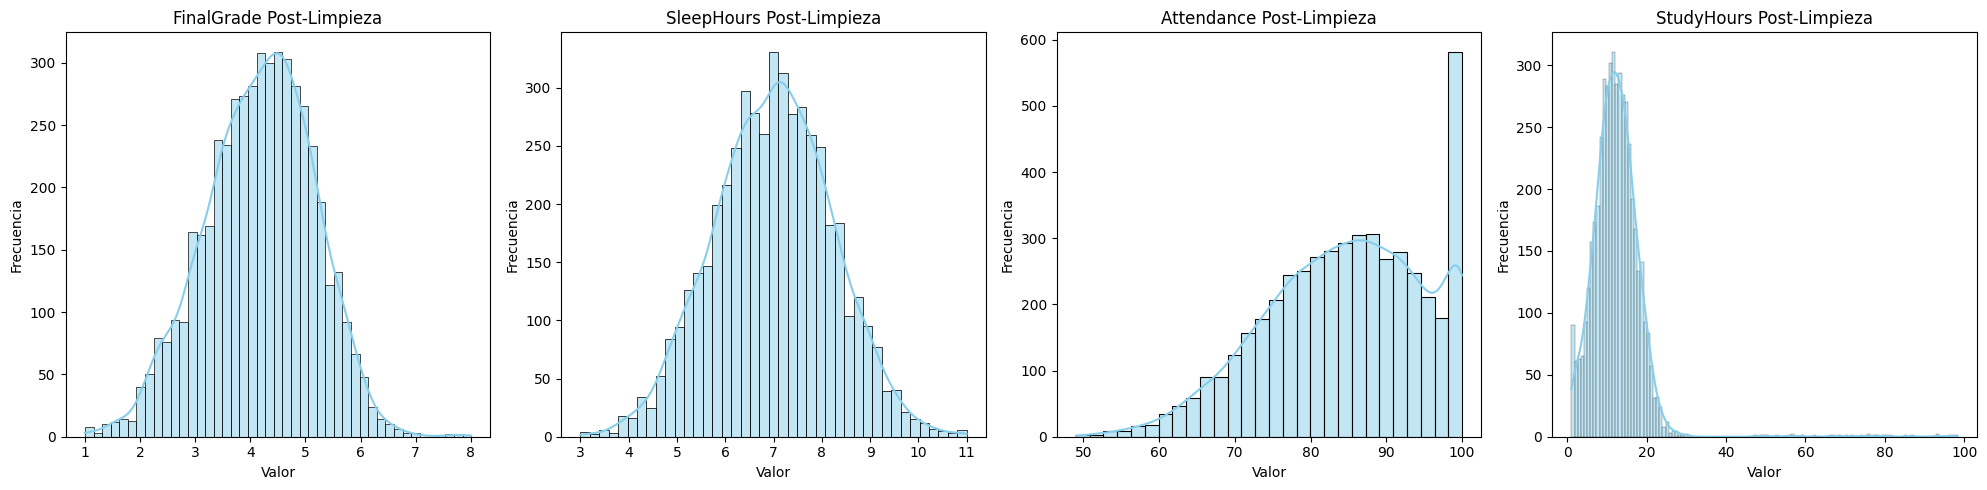

In [48]:
# 3. Visualización de Distribución Limpia
# Comparamos visualmente las variables críticas para confirmar la ausencia de outliers inválidos.
vars_criticas = ['FinalGrade', 'SleepHours', 'Attendance', 'StudyHours']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(vars_criticas):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'{col} Post-Limpieza')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

###3.4.  Imputación Robusta: Se preservó la tendencia central de los datos sin dejar valores nulos, respetando la naturaleza de cada distribución (simétrica vs asimétrica).

---
Justificación: Usamos Media para PreviousGPA (distribución normal) y Mediana para el resto (presencia de outliers/asimetría o 'Efecto Bill Gates').
Justificación: Imputamos con la Moda al ser variables cualitativas.


In [49]:
# --- 3.4 Imputación de Valores Faltantes ---

# A) Variables Numéricas

for index, row in tabla_num.iterrows():
    col = row['Variable']
    estrategia = row['Estrategia de imputación']

    if estrategia == 'Media':
        valor_imputacion = df_clean[col].mean()
    else:
        valor_imputacion = df_clean[col].median()

    df_clean[col] = df_clean[col].fillna(valor_imputacion)

# B) Variables Categóricas
for col in cat_con_na:
    moda = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(moda)

print("Imputación completada.")
# Verificación final
print(f"Valores faltantes totales: {df_clean.isnull().sum().sum()}")
display(df_clean.head())

Imputación completada.
Valores faltantes totales: 4


,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
0,STU-10522,22.0,10.70,83.73,6.09,69.15,6.27,4.39,Sí,Ingeniería Industrial,3.96
1,STU-10947,65.0,9.86,99.60,6.76,76.95,6.52,8.03,No,Ingeniería Informática,5.09
2,STU-11352,26.0,13.43,92.65,6.07,95.99,6.70,6.37,No,Contador Auditor,4.37
3,STU-12298,27.0,20.77,81.73,5.09,90.96,6.16,5.81,No,Contador Auditor,4.02
4,STU-13527,20.0,6.27,70.17,4.84,64.20,6.30,4.10,No,Ingeniería Civil,3.24


In [50]:
print('Valores faltantes después de la primera imputación:')
display(df_clean.isnull().sum()[df_clean.isnull().sum() > 0].to_frame('n_faltantes'))


Valores faltantes después de la primera imputación:


,n_faltantes
FinalGrade,4


In [51]:
# 3.5 Imputación final de FinalGrade
# Imputamos los 4 NaN generados al limpiar inconsistencias en el punto 3.2
final_grade_median = df_clean['FinalGrade'].median()
df_clean['FinalGrade'] = df_clean['FinalGrade'].fillna(final_grade_median)

print(f"Imputación manual de FinalGrade completada con mediana: {final_grade_median:.2f}")
print(f"Total de valores nulos en df_clean: {df_clean.isnull().sum().sum()}")

Imputación manual de FinalGrade completada con mediana: 4.23
Total de valores nulos en df_clean: 0


#### Verificación final de la consistencia cruzada

Ya con la imputación de valores faltantes completa (incluida la de `SleepHours` e `InternetHours`), confirmamos que ese paso no introdujo nuevas violaciones severas: los valores imputados corresponden a la mediana de cada variable (≈7 h para `SleepHours`, ≈6 h para `InternetHours`), muy por debajo de 24 h, por lo que no pueden generar una violación severa por sí solos. (`StudyHours` también se imputa con su mediana, ≈12 h/semana, pero ya no forma parte de esta verificación cruzada — ver nota en 1.4/3.2).


In [52]:
# --- Verificación final: Análisis Comparado sobre df_clean ya imputado ---
suma_si_final = df_clean["SleepHours"] + df_clean["InternetHours"]

print(f"[Post-imputación] SleepHours+InternetHours > 24: {(suma_si_final > 24).sum()} filas "
      f"({(suma_si_final > 24).mean()*100:.2f}%)")

[Post-imputación] SleepHours+InternetHours > 24: 2 filas (0.04%)


Como se esperaba, ningún registro de `df_clean` alcanza el umbral severo definido en el diagnóstico. Las violaciones "leves" que persisten (1.34% del dataset) son intencionales: corresponden al mismo tipo de imprecisión de autorreporte identificada en 1.4, y se mantuvieron sin modificar por la razón ya justificada arriba.




Con esto, el dataset `df_clean` está totalmente libre de duplicados, inconsistencias y valores faltantes, respetando las distribuciones originales mediante una limpieza controlada paso a paso.

### 3.6 Visualización del Dataset Final Limpio

En esta sección validamos gráficamente que el tratamiento de datos fue exitoso.

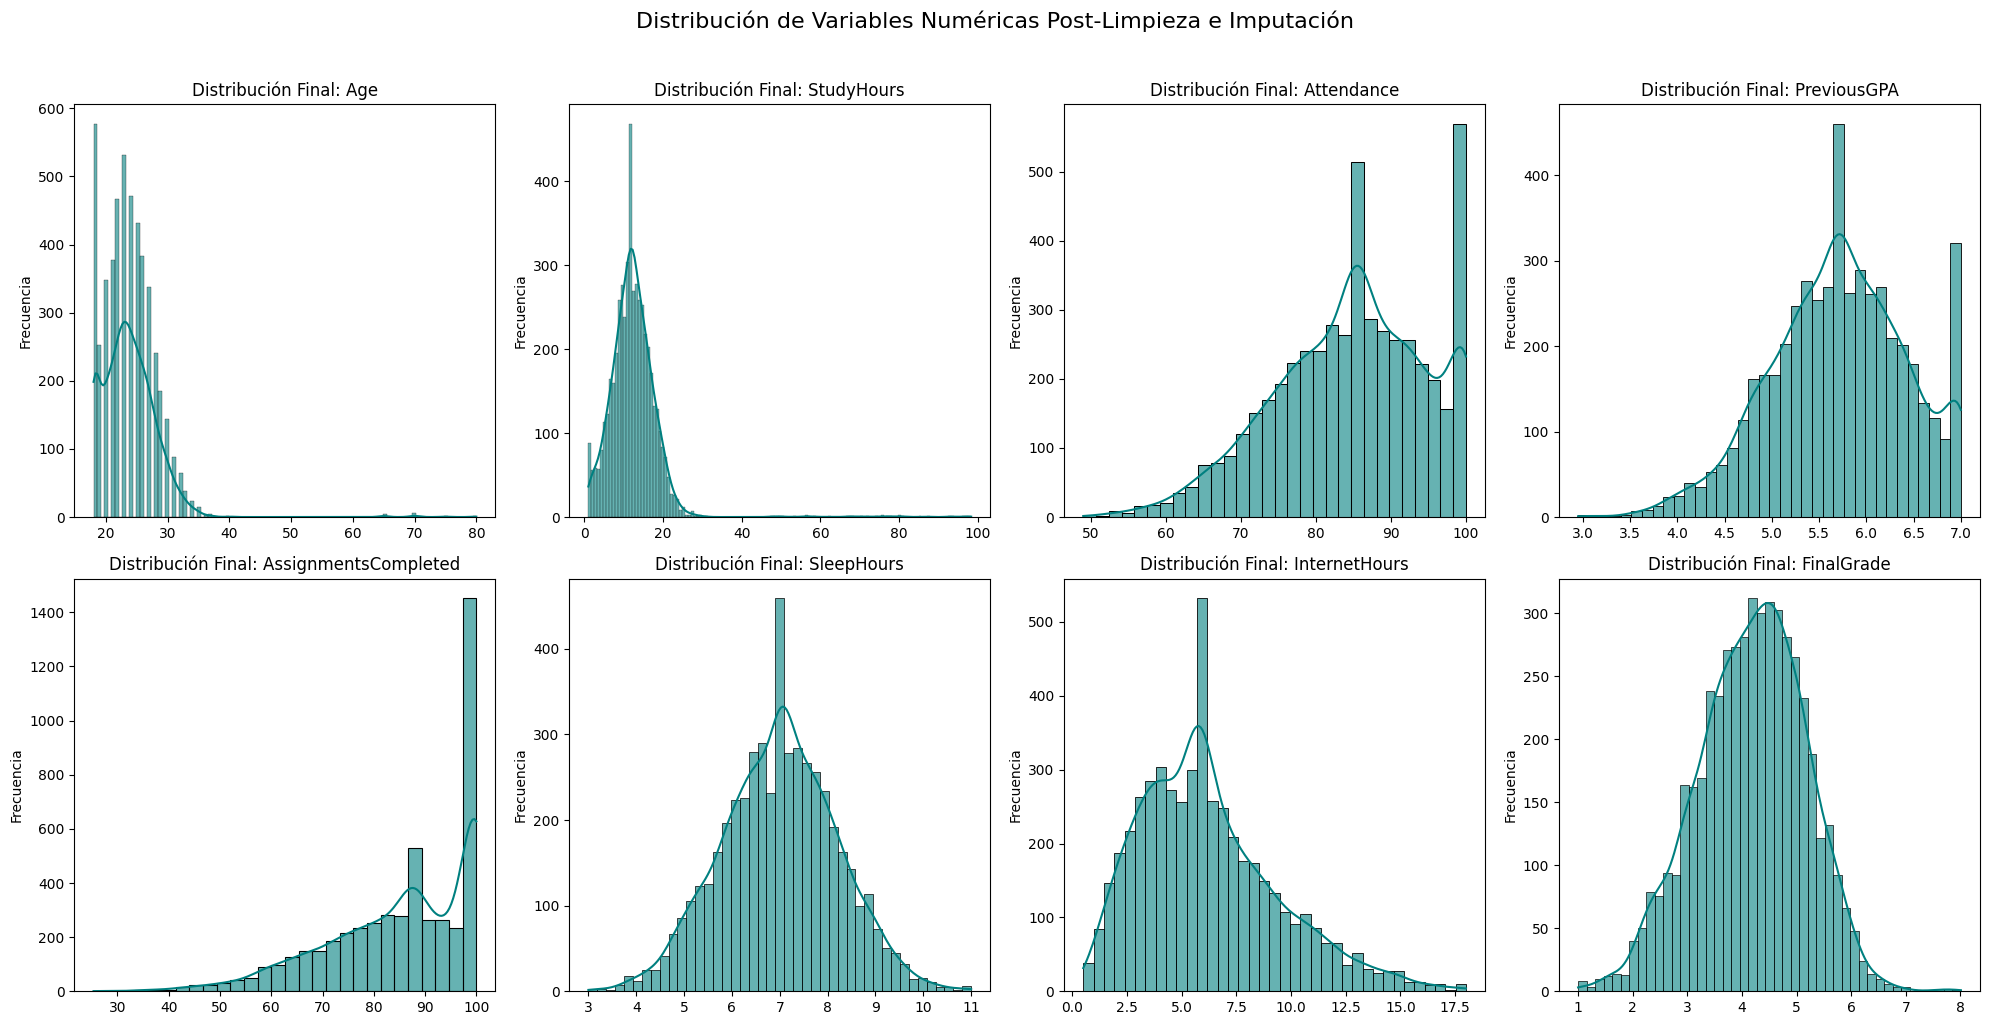

In [53]:
# 1. Histogramas de Distribución Final
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='teal', alpha=0.6)
    axes[i].set_title(f'Distribución Final: {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Numéricas Post-Limpieza e Imputación', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

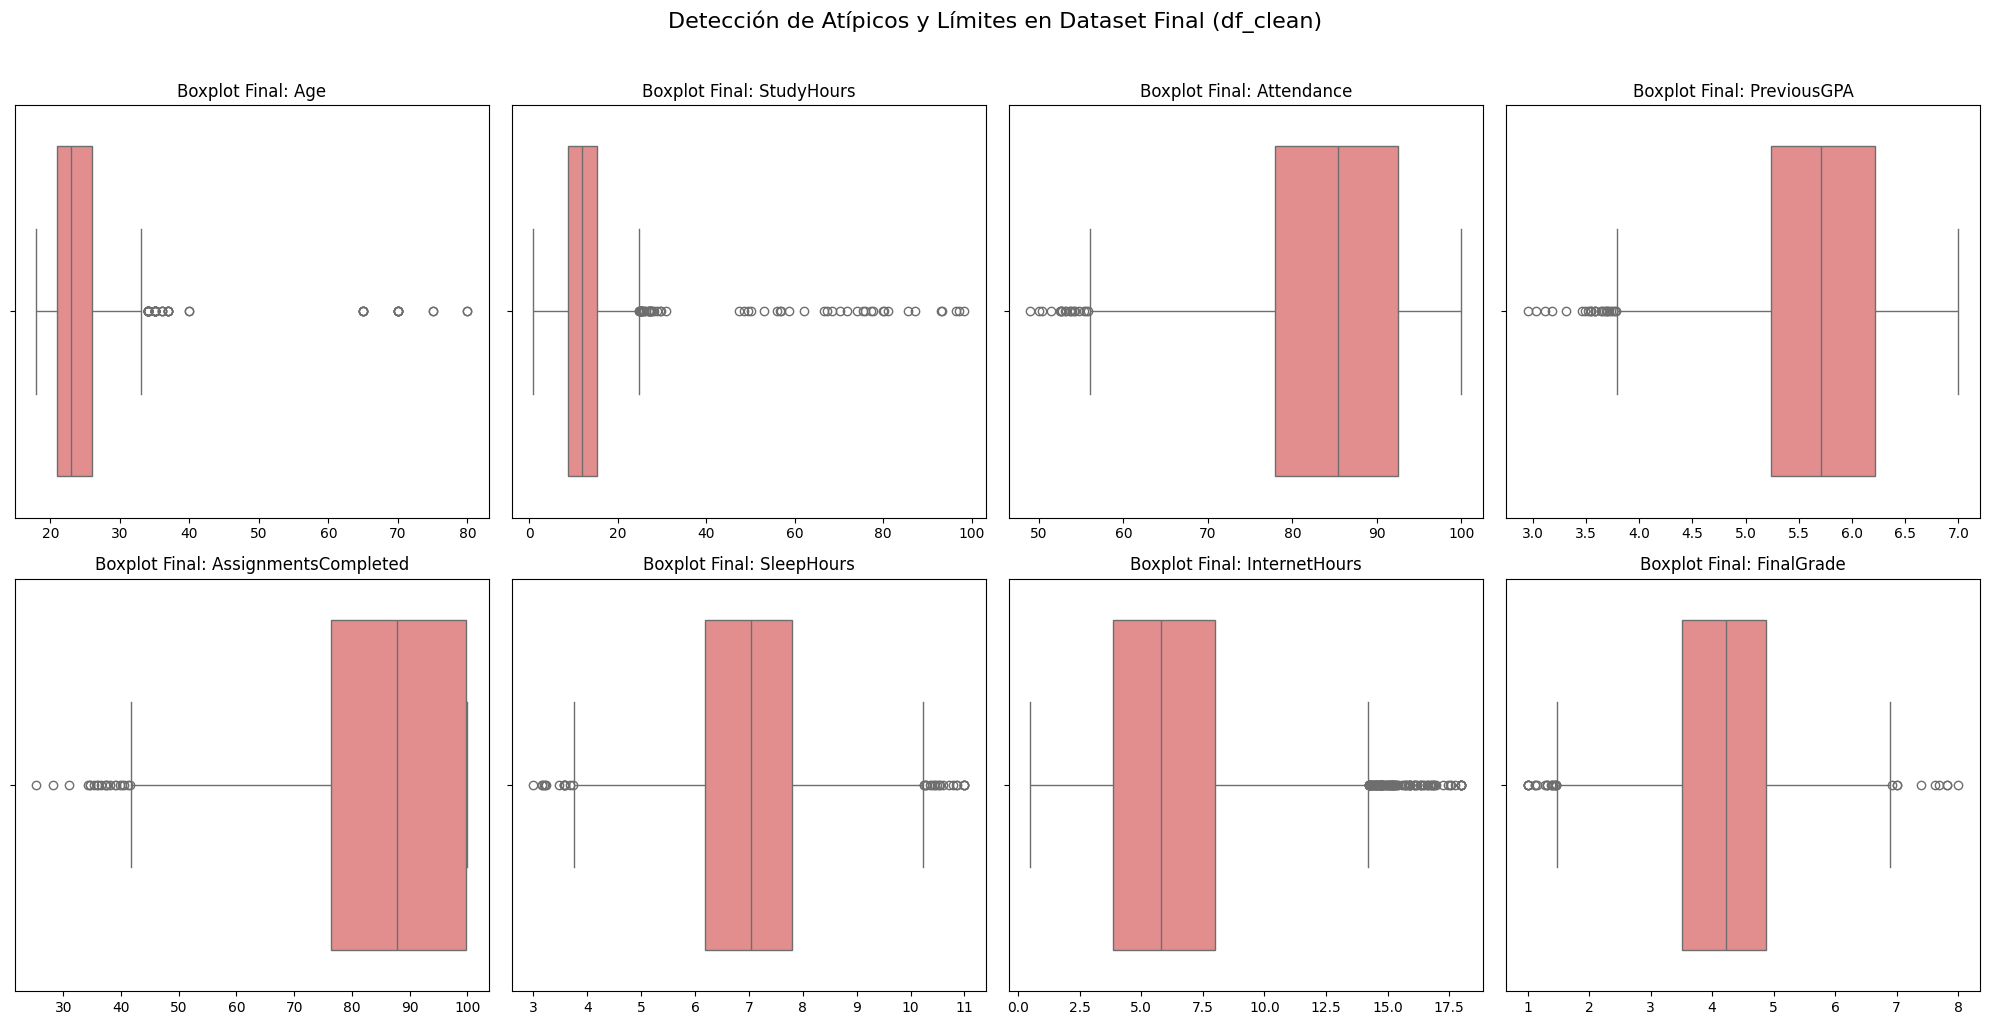

In [54]:
# 2. Boxplots para validación de límites
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    sns.boxplot(x=df_clean[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot Final: {col}')
    axes[i].set_xlabel('')

plt.suptitle('Detección de Atípicos y Límites en Dataset Final (df_clean)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# 4. Implementación mediante Pipeline (20 puntos)



### 4.1 Separación de identificador, variables de entrada (X) y objetivo (y)

Antes de construir el `Pipeline` definimos:

- `StudentID`: se descarta, es solo un identificador y no aporta información predictiva.
- `FinalGrade`: se separa como `y` (variable objetivo) y **nunca** entra al `ColumnTransformer` de las variables de entrada.
- El resto de las columnas forman `X`, y se dividen en dos grupos numéricos (según la estrategia de imputación definida en 1.2) y un grupo de categóricas.

**Sobre los duplicados:** los 100 registros duplicados (1.3) se eliminan **antes** de construir `X` e `y`, fuera del `Pipeline`.

In [55]:
ID_COL = "StudentID"
TARGET_COL = "FinalGrade"

# Dominio válido para las variables de entrada (todo excepto FinalGrade, que se trata aparte)
dominios_X = {col: rango for col, rango in dominios.items() if col != TARGET_COL}
dominio_y = {TARGET_COL: dominios[TARGET_COL]}

# Estrategia de imputación numérica ya calculada en 1.2 (tabla_num)
num_mediana_cols = tabla_num.loc[tabla_num["Estrategia de imputación"] == "Mediana", "Variable"].tolist()
num_media_cols   = tabla_num.loc[tabla_num["Estrategia de imputación"] == "Media", "Variable"].tolist()

# tabla_num solo contiene las numéricas que SÍ tenían NaN en el diagnóstico (1.2).
# Si alguna numérica de entrada no tuviera ningún faltante, no aparecería en tabla_num y
# quedaría fuera de ambos grupos -> el ColumnTransformer la descartaría (remainder="drop").
# Como no tiene NaN, el imputador no le hace nada de todos modos, así que la agregamos
# igual a un grupo (mediana, por defecto) solo para que no se pierda del pipeline.
numericas_X = [c for c in variables_numericas if c != TARGET_COL]
sin_na = [c for c in numericas_X if c not in num_mediana_cols + num_media_cols]
num_mediana_cols += sin_na

# Variables categóricas de entrada (se excluye el identificador)
cat_cols = [c for c in variables_categoricas if c != ID_COL]

print("Numéricas -> Mediana:", num_mediana_cols)
print("Numéricas -> Media   :", num_media_cols)
print("Categóricas          :", cat_cols)

Numéricas -> Mediana: ['Attendance', 'AssignmentsCompleted', 'StudyHours', 'InternetHours', 'SleepHours', 'Age']
Numéricas -> Media   : ['PreviousGPA']
Categóricas          : ['Scholarship', 'Program']


### 4.2 Transformadores personalizados: dominio válido y estandarización categórica

Construimos dos transformadores compatibles con `scikit-learn` (heredan de `BaseEstimator` y `TransformerMixin`) que encapsulan las reglas de limpieza ya definidas en el diagnóstico:

- **`DomainRangeCleaner`**: reemplaza por `NaN` cualquier valor fuera del dominio válido de cada variable (1.4), tal como se hizo manualmente en 3.2. No elimina filas, solo marca como faltante lo que es físicamente imposible, para que después lo trate el imputador correspondiente.
- **`CategoryStandardizer`**: normaliza el texto (mayúsculas, tildes, espacios) y lo mapea a la categoría oficial (1.4/3.3). Cualquier valor que no calce con ninguna categoría conocida se marca como `NaN`, para ser tratado también por el imputador de moda, de forma que el proceso quede completamente automático.

- **`CrossHoursConsistencyCleaner`**: aplica la regla cruzada detectada en el "Análisis Comparado" de 1.4 (`SleepHours + InternetHours` no puede superar 24 horas en un mismo día). Si la suma de ambas variables en una fila supera ese límite, marca **ambas** columnas como `NaN` en esa fila, igual que se hizo manualmente en 3.2, para que el imputador de mediana se encargue después. Esto evita que el Pipeline se limite a validar cada variable por separado y deje pasar inconsistencias que solo aparecen al combinarlas.

Los tres transformadores reutilizan `dominios`, `categorias_oficiales` y `normalizar`, ya definidos en la sección 1.

In [56]:



class DomainRangeCleaner(BaseEstimator, TransformerMixin):
    """Convierte a NaN los valores fuera del dominio válido de cada variable (ver 1.4)."""

    def __init__(self, dominios):
        self.dominios = dominios

    def fit(self, X, y=None):
        # No aprende nada de los datos: las reglas de dominio son fijas
        return self

    def transform(self, X):
        X = X.copy()
        for col, (lo, hi) in self.dominios.items():
            if col in X.columns:
                fuera_de_rango = (X[col] < lo) | (X[col] > hi)
                X.loc[fuera_de_rango, col] = np.nan
        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features)


class CrossHoursConsistencyCleaner(BaseEstimator, TransformerMixin):
    """Marca como NaN SleepHours e InternetHours en filas donde su suma supera max_total
    horas en un mismo día (regla cruzada detectada en el Análisis Comparado de 1.4, y
    tratada manualmente en 3.2). No elimina filas, solo marca como faltante lo que es
    físicamente imposible, para que después lo trate el imputador correspondiente."""

    def __init__(self, col_a="SleepHours", col_b="InternetHours", max_total=24):
        self.col_a = col_a
        self.col_b = col_b
        self.max_total = max_total

    def fit(self, X, y=None):
        # No aprende nada de los datos: la regla es fija
        return self

    def transform(self, X):
        X = X.copy()
        if self.col_a in X.columns and self.col_b in X.columns:
            suma = X[self.col_a] + X[self.col_b]
            inconsistente = suma > self.max_total
            X.loc[inconsistente, [self.col_a, self.col_b]] = np.nan
        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features)


class CategoryStandardizer(BaseEstimator, TransformerMixin):
    """Estandariza texto y lo mapea a su categoría oficial; lo no reconocido -> NaN (ver 1.4/3.3)."""

    def __init__(self, categorias_oficiales):
        self.categorias_oficiales = categorias_oficiales

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col, oficiales in self.categorias_oficiales.items():
            if col in X.columns:
                X[col] = X[col].apply(
                    lambda v: v if pd.isna(v) else oficiales.get(normalizar(v), np.nan)
                )
        return X

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features)

### 4.3 `ColumnTransformer`: imputación, tratamiento de outliers y codificación

El `ColumnTransformer` aplica, en paralelo, una transformación distinta a cada grupo de columnas:

- **Numéricas (mediana)**: `SimpleImputer(strategy="median")` para las variables donde 1.2 detectó asimetría/outliers relevantes ("efecto Bill Gates").
- **Numéricas (media)**: `SimpleImputer(strategy="mean")` para `PreviousGPA`, la única variable numérica con distribución suficientemente simétrica.
- **Categóricas**: `SimpleImputer(strategy="most_frequent")` (moda) seguido de `OneHotEncoder` (variables nominales, sin orden natural). Se usa `drop="if_binary"` para que `Scholarship` (Sí/No) quede codificada en una sola columna en vez de dos redundantes.

**Estrategia de outliers:** en 1.5 concluimos que los valores fuera de dominio (inválidos) deben tratarse como faltantes, mientras que los valores extremos pero válidos (p. ej. edades altas, notas previas bajas) deben **conservarse**, para no perder variabilidad real de la población. Por eso, después de imputar, escalamos todas las variables numéricas con `RobustScaler` (usa mediana y rango intercuartílico) en lugar de `StandardScaler`: así los valores extremos legítimos no distorsionan la escala del resto de los datos, sin necesidad de eliminarlos ni recortarlos artificialmente.

In [57]:
def construir_pipeline_features():
    """Crea un Pipeline nuevo (sin estado previo) para las variables de entrada X."""
    preprocesador = ColumnTransformer(
        transformers=[
            ("num_mediana", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", RobustScaler()),
            ]), num_mediana_cols),
            ("num_media", Pipeline([
                ("imputer", SimpleImputer(strategy="mean")),
                ("scaler", RobustScaler()),
            ]), num_media_cols),
            ("categoricas", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False)),
            ]), cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    # Devuelve un DataFrame (con nombres de columna) en vez de un array de numpy
    preprocesador.set_output(transform="pandas")

    return Pipeline([
        ("limpieza_dominio", DomainRangeCleaner(dominios_X)),
        ("consistencia_cruzada_horas", CrossHoursConsistencyCleaner()),
        ("estandarizacion_categorica", CategoryStandardizer(categorias_oficiales)),
        ("preprocesamiento", preprocesador),
    ])


def construir_pipeline_target():
    """Pipeline separado y más simple para FinalGrade: limpieza de dominio + imputación con mediana."""
    return Pipeline([
        ("limpieza_dominio", DomainRangeCleaner(dominio_y)),
        ("imputer", SimpleImputer(strategy="median")),
    ])

### 4.4 Función reproducible: `df_original` → dataset tratado

`preparar_dataset` encapsula todo el proceso: elimina duplicados, separa `X`/`y`, y aplica un `Pipeline` distinto (pero igual de reproducible) a cada uno. Cada llamada construye pipelines nuevos y sin estado previo, por lo que ejecutar la función dos veces sobre `df_original` siempre entrega exactamente el mismo resultado.

In [58]:
def preparar_dataset(df_crudo):
    """Ejecuta el proceso completo de tratamiento sobre un dataset crudo y devuelve el dataset tratado."""
    # 1) Duplicados exactos fuera (ver justificación en 4.1)
    df_dedup = df_crudo.drop_duplicates().reset_index(drop=True)

    # 2) Separar identificador, variables de entrada (X) y variable objetivo (y)
    X = df_dedup.drop(columns=[ID_COL, TARGET_COL])
    y = df_dedup[[TARGET_COL]]

    # 3) Pipelines nuevos (sin estado previo) para X e y
    pipeline_features = construir_pipeline_features()
    pipeline_target = construir_pipeline_target()

    X_tratado = pipeline_features.fit_transform(X)
    y_tratado = pd.DataFrame(
        pipeline_target.fit_transform(y), columns=[TARGET_COL], index=X_tratado.index
    )

    # 4) Dataset final (se conserva StudentID solo como referencia/trazabilidad)
    dataset_tratado = pd.concat(
        [df_dedup[[ID_COL]].reset_index(drop=True),
         X_tratado.reset_index(drop=True),
         y_tratado.reset_index(drop=True)],
        axis=1,
    )
    return dataset_tratado, pipeline_features, pipeline_target

### 4.5 Ejecución y verificación

Ejecutamos el proceso sobre `df_original` (el dataset tal como se descargó, sin ningún tratamiento previo) y verificamos que:

1. Los 100 duplicados se eliminan (5.100 → 5.000 filas).
2. No quedan valores faltantes.
3. `FinalGrade` no fue escalada ni codificada: se mantiene en su escala original [1.0, 10.0], solo se limpió su dominio y se imputó.
4. Ejecutar el proceso dos veces produce exactamente el mismo resultado (reproducibilidad).

In [59]:
dataset_tratado, pipeline_features, pipeline_target = preparar_dataset(df_original)

print("="*60)
print("4.5 RESULTADO DEL PIPELINE")
print("="*60)
print(f"Filas dataset original  : {df_original.shape[0]}")
print(f"Filas dataset tratado   : {dataset_tratado.shape[0]}  (100 duplicados eliminados)")
print(f"Columnas dataset tratado: {dataset_tratado.shape[1]}")
print(f"Valores nulos restantes : {dataset_tratado.isnull().sum().sum()}")
print(f"Rango de FinalGrade tratado (debe seguir en su escala original [1.0, 10.0]): "
      f"[{dataset_tratado['FinalGrade'].min():.2f}, {dataset_tratado['FinalGrade'].max():.2f}]")
print()
dataset_tratado.head()

4.5 RESULTADO DEL PIPELINE
Filas dataset original  : 5100
Filas dataset tratado   : 5000  (100 duplicados eliminados)
Columnas dataset tratado: 15
Valores nulos restantes : 0
Rango de FinalGrade tratado (debe seguir en su escala original [1.0, 10.0]): [1.00, 8.01]



,StudentID,Attendance,AssignmentsCompleted,StudyHours,InternetHours,SleepHours,Age,PreviousGPA,Scholarship_Sí,Program_Administración,Program_Contador Auditor,Program_Ingeniería Civil,Program_Ingeniería Industrial,Program_Ingeniería Informática,FinalGrade
0,STU-10522,-0.116156,-0.798539,-0.205894,-0.325301,-0.462963,-0.2,0.389241,1.0,0.0,0.0,0.0,1.0,0.0,3.96
1,STU-10947,0.971389,-0.463307,-0.337917,0.551807,-0.308642,8.4,1.078187,0.0,0.0,0.0,0.0,0.0,1.0,5.09
2,STU-11352,0.495117,0.355002,0.223183,0.151807,-0.197531,0.6,0.368676,0.0,0.0,1.0,0.0,0.0,0.0,4.37
3,STU-12298,-0.253212,0.138820,1.376817,0.016867,-0.530864,0.8,-0.639036,0.0,0.0,1.0,0.0,0.0,0.0,4.02
4,STU-13527,-1.045400,-1.011282,-0.902161,-0.395181,-0.444444,-0.6,-0.896106,0.0,0.0,0.0,1.0,0.0,0.0,3.24


In [60]:
# Reproducibilidad: volver a ejecutar el proceso completo sobre el dataset original
dataset_tratado_2, _, _ = preparar_dataset(df_original)

print("¿El resultado es idéntico al volver a ejecutar el proceso sobre df_original?",
      dataset_tratado.equals(dataset_tratado_2))

¿El resultado es idéntico al volver a ejecutar el proceso sobre df_original? True


### 4.6 Verificación de la regla cruzada (SleepHours + InternetHours)

A continuación se comprueba el efecto de la regla SleepHours + InternetHours

In [61]:
# Violaciones de la regla cruzada ANTES de aplicar CrossHoursConsistencyCleaner
# (pero ya con la limpieza de dominio individual aplicada, igual que en 3.2)
X_check = df_original.drop_duplicates().reset_index(drop=True).drop(columns=[ID_COL, TARGET_COL])
X_check = DomainRangeCleaner(dominios_X).transform(X_check)

antes = int((X_check["SleepHours"] + X_check["InternetHours"] > 24).sum())

# Después de aplicar la regla cruzada + imputación por mediana (igual que hace el Pipeline)
X_corregido = CrossHoursConsistencyCleaner().transform(X_check)
sleep_imp = X_corregido["SleepHours"].fillna(X_corregido["SleepHours"].median())
internet_imp = X_corregido["InternetHours"].fillna(X_corregido["InternetHours"].median())

despues = int((sleep_imp + internet_imp > 24).sum())

print("="*60)
print("4.6 VERIFICACIÓN REGLA CRUZADA (SleepHours + InternetHours <= 24)")
print("="*60)
print(f"Violaciones antes de corregir la regla cruzada : {antes}")
print(f"Violaciones residuales tras imputar por mediana : {despues}")
print("(residual esperado y aceptado, igual que en 3.x: imputar cada variable por su\n"
      " propia mediana global no garantiza que la suma quede siempre bajo 24h)")


4.6 VERIFICACIÓN REGLA CRUZADA (SleepHours + InternetHours <= 24)
Violaciones antes de corregir la regla cruzada : 65
Violaciones residuales tras imputar por mediana : 2
(residual esperado y aceptado, igual que en 3.x: imputar cada variable por su
 propia mediana global no garantiza que la suma quede siempre bajo 24h)


**Resumen:** el tratamiento completo (limpieza de dominio, estandarización de texto, imputación numérica/categórica, tratamiento robusto de outliers y codificación) queda encapsulado en objetos `Pipeline`/`ColumnTransformer` de `scikit-learn`, sin transformaciones manuales de pandas sueltas (aparte de la eliminación de duplicados, justificada en 4.1). `FinalGrade` permanece separada como variable objetivo durante todo el proceso, y `preparar_dataset(df_original)` puede ejecutarse las veces que sea necesario, entregando siempre el mismo dataset tratado, listo para alimentar un modelo predictivo.

# 5. Dataset final y evidencia

Una vez aplicadas las estrategias de limpieza y transformación definidas en las etapas anteriores, se generó un nuevo dataset tratado. En esta sección se verifica la calidad de los datos resultantes y se compara su estado con el dataset original, con el objetivo de comprobar que los problemas identificados durante el diagnóstico fueron abordados correctamente.

###5.1 Dataset final
En este punto se genera el DataFrame final a partir del dataset tratado mediante el proceso de preparación definido anteriormente. Se realiza una copia del resultado para conservar el dataset tratado y posteriormente verificar sus características.

Se comprueba la cantidad final de registros y variables, además de verificar la existencia de valores faltantes. También se muestran los primeros registros y la estructura del DataFrame para comprobar que el resultado mantiene un formato adecuado para su utilización posterior.

In [62]:
# ============================================================
# 5. DATASET FINAL Y EVIDENCIA
# ============================================================

# 5.1 Generación del dataset final
df_final2 = dataset_tratado.copy()

print("="*60)
print("5.1 DATASET FINAL")
print("="*60)

print(f"Cantidad de registros : {df_final2.shape[0]}")
print(f"Cantidad de variables : {df_final2.shape[1]}")
print(f"Valores faltantes     : {df_final2.isnull().sum().sum()}")

display(df_final2.head())

df_final2.info()

5.1 DATASET FINAL
Cantidad de registros : 5000
Cantidad de variables : 15
Valores faltantes     : 0


,StudentID,Attendance,AssignmentsCompleted,StudyHours,InternetHours,SleepHours,Age,PreviousGPA,Scholarship_Sí,Program_Administración,Program_Contador Auditor,Program_Ingeniería Civil,Program_Ingeniería Industrial,Program_Ingeniería Informática,FinalGrade
0,STU-10522,-0.116156,-0.798539,-0.205894,-0.325301,-0.462963,-0.2,0.389241,1.0,0.0,0.0,0.0,1.0,0.0,3.96
1,STU-10947,0.971389,-0.463307,-0.337917,0.551807,-0.308642,8.4,1.078187,0.0,0.0,0.0,0.0,0.0,1.0,5.09
2,STU-11352,0.495117,0.355002,0.223183,0.151807,-0.197531,0.6,0.368676,0.0,0.0,1.0,0.0,0.0,0.0,4.37
3,STU-12298,-0.253212,0.138820,1.376817,0.016867,-0.530864,0.8,-0.639036,0.0,0.0,1.0,0.0,0.0,0.0,4.02
4,STU-13527,-1.045400,-1.011282,-0.902161,-0.395181,-0.444444,-0.6,-0.896106,0.0,0.0,0.0,1.0,0.0,0.0,3.24


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   StudentID                       5000 non-null   object 
 1   Attendance                      5000 non-null   float64
 2   AssignmentsCompleted            5000 non-null   float64
 3   StudyHours                      5000 non-null   float64
 4   InternetHours                   5000 non-null   float64
 5   SleepHours                      5000 non-null   float64
 6   Age                             5000 non-null   float64
 7   PreviousGPA                     5000 non-null   float64
 8   Scholarship_Sí                  5000 non-null   float64
 9   Program_Administración          5000 non-null   float64
 10  Program_Contador Auditor        5000 non-null   float64
 11  Program_Ingeniería Civil        5000 non-null   float64
 12  Program_Ingeniería Industrial   50

###5.2 Verificación final de calidad
Después de aplicar las transformaciones, se realiza una nueva evaluación de calidad sobre el dataset final. El objetivo es comprobar que los problemas detectados durante el diagnóstico inicial fueron corregidos de acuerdo con las estrategias definidas.

Se verifican principalmente los siguientes aspectos:

valores faltantes restantes;
registros duplicados;
valores fuera de los rangos permitidos;
categorías no estandarizadas o inválidas;
valores atípicos inválidos restantes.

Esta verificación permite contrastar el estado final de los datos con los problemas encontrados inicialmente y comprobar que el proceso de limpieza fue aplicado correctamente

In [63]:
print("="*60)
print("5.2 VERIFICACION FINAL DE CALIDAD")
print("="*60)

# 1. Valores faltantes
n_faltantes_final = int(df_final2.isnull().sum().sum())

# 2. Registros duplicados
n_duplicados_final = int(df_final2.duplicated().sum())

# 3. Valores fuera de dominio (Inconsistencias)
# Verificamos si queda algun nulo en las columnas numericas tras el DomainRangeCleaner del Pipeline
columnas_num = num_mediana_cols + num_media_cols
valores_fuera_dominio_final = int(df_final2[columnas_num].isnull().sum().sum())

# 4. Categorias no estandarizadas
# Si el OneHotEncoder funcione correctamente, no quedan nulos en las categericas originales
categorias_invalidas_final = int(df_final2.filter(like='Program').isnull().sum().sum())

# 5. Outliers invalidos restantes (basado en el dominio)
outliers_invalidos_final = valores_fuera_dominio_final

print(f"Valores faltantes restantes        : {n_faltantes_final}")
print(f"Registros duplicados restantes     : {n_duplicados_final}")
print(f"Valores fuera de dominio           : {valores_fuera_dominio_final}")
print(f"Categorias no estandarizadas       : {categorias_invalidas_final}")
print(f"Outliers invalidos restantes       : {outliers_invalidos_final}")

5.2 VERIFICACION FINAL DE CALIDAD
Valores faltantes restantes        : 0
Registros duplicados restantes     : 0
Valores fuera de dominio           : 0
Categorias no estandarizadas       : 0
Outliers invalidos restantes       : 0


###5.3 Comparación Dataset original y Dataset tratado
Finalmente, se realiza una comparación entre el dataset original y el dataset tratado. Para ello se consideran indicadores de calidad relevantes, tales como la cantidad de registros, cantidad de variables, valores faltantes, registros duplicados, inconsistencias y outliers inválidos.

Esta comparación permite evidenciar el efecto del proceso de preparación y determinar si las estrategias aplicadas permitieron mejorar la calidad del conjunto de datos.

**Nota sobre las dos últimas filas:** "Inconsistencias" (134) corresponde al total de violaciones de dominio detectadas en 1.4 (63 numéricas + 71 categóricas). "Outliers tratados" (55) es un subconjunto distinto: solo los valores fuera de dominio que además fueron marcados como atípicos por la regla IQR en 1.5. No son aditivos ni independientes entre sí — se muestran por separado porque provienen de dos análisis distintos (1.4 y 1.5), no porque midan cosas distintas del dataset tratado.

In [64]:
# --- Dataset ORIGINAL (Valores estaticos del diagnostico inicial) ---
n_registros_original = 5100
n_variables_original = 11
n_faltantes_original = 1335
n_duplicados_original = 100
inconsistencias_original = 134 # (63 numericas + 71 categoricas)
outliers_invalidos_original = 55

# --- Dataset TRATADO (Calculo real sobre df_final) ---
n_registros_final = len(df_final2)
n_variables_final = df_final2.shape[1]
n_faltantes_final = int(df_final2.isnull().sum().sum())
n_duplicados_final = int(df_final2.duplicated().sum())
# Inconsistencias finales sumando errores de dominio y formato (deben ser 0)
inconsistencias_final = valores_fuera_dominio_final + categorias_invalidas_final
outliers_invalidos_final = valores_fuera_dominio_final

comparacion_final = pd.DataFrame({
    "Indicador": [
        "Cantidad de registros",
        "Cantidad de variables",
        "Valores faltantes",
        "Registros duplicados",
        "Inconsistencias",
        "Outliers tratados"
    ],
    "Dataset original": [
        n_registros_original,
        n_variables_original,
        n_faltantes_original,
        n_duplicados_original,
        inconsistencias_original,
        outliers_invalidos_original
    ],
    "Dataset tratado": [
        n_registros_final,
        n_variables_final,
        n_faltantes_final,
        n_duplicados_final,
        inconsistencias_final,
        outliers_invalidos_final
    ]
})

display(comparacion_final)

,Indicador,Dataset original,Dataset tratado
0,Cantidad de registros,5100,5000
1,Cantidad de variables,11,15
2,Valores faltantes,1335,0
3,Registros duplicados,100,0
4,Inconsistencias,134,0
5,Outliers tratados,55,0


###5.4 Exportación del Dataset tratado
Una vez finalizado el proceso de tratamiento y verificada la calidad de los datos, se procedió a exportar el DataFrame final a un archivo en formato CSV.

In [65]:
# ============================================================
# 5.4 EXPORTACIÓN DEL DATASET FINAL
# ============================================================

nombre_archivo = "rendimiento_academico_limpio.csv"

df_final2.to_csv(nombre_archivo, index=False, encoding="utf-8-sig")

print("="*60)
print("5.4 EXPORTACIÓN DEL DATASET")
print("="*60)
print(f"Archivo generado: {nombre_archivo}")
print(f"Cantidad de registros exportados: {df_final2.shape[0]}")
print(f"Cantidad de variables exportadas: {df_final2.shape[1]}")

5.4 EXPORTACIÓN DEL DATASET
Archivo generado: rendimiento_academico_limpio.csv
Cantidad de registros exportados: 5000
Cantidad de variables exportadas: 15


###5.5 Descarga del Dataset

In [66]:

files.download("rendimiento_academico_limpio.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>